In [198]:
#!/usr/bin/env python
# coding: utf-8

"""
Title: Clean Clustered Xenium QC And Inspection
Date: 2026-06-29
Summary: Run QC and exploratory spatial plots from clean expression AnnData
objects that already contain BANKSY cluster labels and embeddings.
"""



'\nTitle: Clean Clustered Xenium QC And Inspection\nDate: 2026-06-29\nSummary: Run QC and exploratory spatial plots from clean expression AnnData\nobjects that already contain BANKSY cluster labels and embeddings.\n'

In [199]:


# ---------------------------------------------------------------------------- #
#                            01 - Xenium QC analysis                           #
# ---------------------------------------------------------------------------- #
## Date: April 2026
## Author: Nathalie Nataren




In [200]:


### Import packages
import anndata as ad
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import squidpy as sq
import matplotlib as mpl
from matplotlib import rc_context
import random
import dask
dask.config.set({"dataframe.query-planning": True})
 
import warnings
warnings.filterwarnings("ignore") 

# Note that BANKSY itself is deterministic, here the seeds affect the umap clusters and leiden partition
seed = 1234
np.random.seed(seed)
random.seed(seed)





In [201]:


# # ---------------------------------------------------------------------------- #
# #                              LOCAL TESTING BLOCK                             #
# # ---------------------------------------------------------------------------- #

# ## These values mirror config/01_clustering/vbct/small/CK_skin_res.json.
# ## Leave this block commented when using --config from Slurm/the shell.
# dataset_name = "CK_skin_res"
# pc_label = "30"
# pc_dims = [int(pc_label)]
# lambda_label = "0.20"
# lambda_list = [float(lambda_label)]
# res_label = ["0.70", "0.80", "0.90", "1.00"]
# res_label_list = res_label
# resolutions = [float(res) for res in res_label_list]
# plot_res_label = "1.00"
# nbr_weight_decay = "scaled_gaussian"
# coord_keys = ("x", "y", "xy")
# project = "vbct"
# raw_subdir = "vbct"
# res_str = "_".join(res_label_list)
# cluster_col = "labels_scaled_gaussian_pc30_nc0.20_r1.00"
# cluster_ann_col = f"{cluster_col}_ann"

# new_labels = {
#     "0": "Differentiated_melanoma_cells_(MITF+)_0",
#     "1": "Cancer_associated_fibroblasts_1",
#     "2": "M2-like_tumour_associated_macrophages_2",
#     "3": "Myofibroblasts_3",
#     "4": "Vascular_endothelial_cells_4",
#     "5": "C8+_T_cells_(ITGA4)_5",
# }




In [202]:


# --------------------- PARSE ARGUMENTS FROM JSON CONFIG --------------------- #

# This block of code feeds arguments to this python script from a config files found in /config

## Import argparse and json packages to read in variables from the per sample .json config files 
import argparse
import json


parser = argparse.ArgumentParser(prog="used to parse arguments from 01_QC_xenium_spatial_clean_clustered.py") # Initialise the parser
parser.add_argument("--config", type=str, help="Optional JSON config file for each Xenium sample", required=False) # This defines the flag and tells the script to look for a JSON config
# parse_known_args keeps notebook/kernel arguments from breaking local runs.
args, _unknown_args = parser.parse_known_args()

#"res_label": ["0.50", "0.60", "0.70", "0.80", "0.90", "1.00", "1.10"],

if args.config:
    with open(args.config) as f: # Opens the file path provided by the user
        cfg = json.load(f) # Converts the json config into a python dictionary called "cfg"
else:
    print("No --config supplied; using CK_skin_res local testing defaults.")
    cfg = {
        "project": "vbct",
        "raw_subdir": "vbct",
        "dataset_name": "CK_skin_res",
        "pc_label": "30",
        "lambda_label": "0.20",
        "res_label": ["0.50", "0.60", "0.70", "0.80", "0.90", "1.00", "1.10"],
        "plot_res_label": "0.70",
        "nbr_weight_decay": "scaled_gaussian",
        "coord_keys": ["x", "y", "xy"],
        "cluster_col": "labels_scaled_gaussian_pc30_nc0.20_r0.70",
        "new_labels": {
            "0": "Melanoma_Cell_or_Melanocyte_0",
            "1": "Fibroblast_and_Macrophage_1",
            "2": "Macrophage_Fibroblast_2",
            "3": "Fibroblast_3",
            "4": "T_Cell_with_Macrophages_and_Fibroblast_4",
            "5": "Macrophage_5",
            "6": "Endothelial_Cell_with_Fibroblast_Pericytes_6",
            "7": "Fibroblast_7",
            "8": "Melanoma_Cell_or_Melanocyte_8",
        },
    }


## Set the dataset_name and related settings to use during this analysis by taking the argument values from the "cfg" dictionary read in from the JSON config
dataset_name = cfg["dataset_name"] # sample name
pc_label = cfg["pc_label"] # Label for the number of principal components used for the purpose of filenames
pc_dims = [int(pc_label)] # The number of principal components stored a list for analyses
lambda_label = cfg["lambda_label"] # File name label for Lambda setting, see comment below. 
lambda_list = [float(lambda_label)] # Lambda setting to tune BANKSY clustering, lambda = 0 is non-spatial, 0.2 is for cell typing, 0.8 if for domain segmentation 
res_label = cfg["res_label"] # BANKSY clustering resolution label(s) used in the clean clustered object filename
res_label_list = res_label if isinstance(res_label, list) else [res_label]
resolutions = [float(res) for res in res_label_list] # BANSY can take a list of resolutions and perform clustering at each which is saved in the BANKSY dictionary
plot_res_label = cfg.get("plot_res_label", res_label_list[-1]) # Resolution label to use for cluster-coloured QC plots
nbr_weight_decay = cfg["nbr_weight_decay"] # This parameter dictates how much neighbouring cells impact to the neighbourhood expression calculations. Using scaled gaussian, the 
# close neigbours contribute more and this decays as you move out to cells further away in the neighbourhood window. It is scaled for local cell density so that weighting doesn't change
# across regions if cells are pack more closely or loosely in different regions

coord_keys = tuple(cfg["coord_keys"]) # Keys to specify coordinate indexes in the anndata Object
project = cfg.get("project", "")
raw_subdir = cfg.get("raw_subdir", "")
res_str = "_".join(res_label_list)
plot_res_float = float(plot_res_label)
cluster_col = cfg.get("cluster_col", f"labels_scaled_gaussian_pc{pc_label}_nc{lambda_label}_r{plot_res_float:.2f}")
cluster_ann_col = f"{cluster_col}_ann"
new_labels = cfg.get("new_labels", {}) # These are the cluster labels for cell types




No --config supplied; using CK_skin_res local testing defaults.


In [ ]:
def plot_qc_spatial_tissue(
    data,
    qc_metric,
    sample_name,
    output_path=None,
    show=True
):
    """
    Plot the spatial location of cells coloured by a QC metric.

    Parameters
    ----------
    data : anndata.AnnData
        AnnData object containing spatial coordinates in `.obsm['xy']` and the
        requested QC metric in `.obs`.
    qc_metric : str
        Name of the `.obs` column to use for colouring cells in the tissue plot.
    sample_name : str
        Sample name used in the output filename and status message.
    output_path : str or None
        Directory in which to save the figure. Defaults to `qc_path`.
    show : bool
        Whether to display the plot.

    Returns
    -------
    None
        Saves a PNG spatial scatter plot to `output_path`.
    """

    if output_path is None:
        output_path = qc_path

    os.makedirs(output_path, exist_ok=True)

    with rc_context({"figure.figsize": (12, 8)}):
        sq.pl.spatial_scatter(
            data,
            library_id="dataset_name",
            spatial_key="xy",
            color=f"{qc_metric}",
            shape=None,
            size=2,
            img=False
        )
        plt.legend(fontsize=20)

    output_file = os.path.join(
        output_path,
        f"tissue_spatial_scatter_min_{qc_metric}_{sample_name}.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved figure to: {output_file}")

    if show:
        plt.show()
    else:
        plt.close()


def cluster_qc_violin(
    data,
    cluster_col,
    qc_metric,
    sample_name,
    qc_title=None,
    output_path=None,
    filename_prefix="cluster_qc_violin",
    filename_tag=None,
    title_tag=None,
    show=True
):
    """
    Plot per-cluster transcript-count distributions with QC status overlaid.

    Parameters
    ----------
    data : anndata.AnnData
        AnnData object containing `nCount_Xenium`, the requested cluster column,
        and the requested QC metric in `.obs`.
    cluster_col : str
        Name of the `.obs` column used to group cells along the x-axis.
    qc_metric : str
        Name of the `.obs` column used to colour the overlaid stripplot points.
        This is typically a categorical pass/fail QC column.
    sample_name : str
        Sample name used in the plot title and output filename.
    qc_title : str or None
        Human-readable QC metric label for the plot title.
    output_path : str or None
        Directory in which to save the figure. Defaults to `qc_path`.
    filename_prefix : str
        Prefix used for the saved figure name.
    filename_tag : str or None
        Optional tag appended to the saved figure name, for example `r0.70`.
    title_tag : str or None
        Optional text appended to the plot title.
    show : bool
        Whether to display the plot.

    Returns
    -------
    None
        Saves a PNG violin plot to `output_path` and leaves the active
        Matplotlib figure available for display in the notebook.
    """

    required_cols = ["nCount_Xenium", cluster_col, qc_metric]
    missing_cols = [
        col for col in required_cols
        if col not in data.obs.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Columns not found in data.obs: {missing_cols}"
        )

    plot_obs = data.obs.copy()
    plot_obs[cluster_col] = plot_obs[cluster_col].astype("category")
    plot_obs[qc_metric] = plot_obs[qc_metric].astype("category")

    cell_types = plot_obs[cluster_col].cat.categories
    n_cell_types = len(cell_types)

    palette = dict(zip(
        cell_types,
        sns.color_palette("husl", n_colors=n_cell_types)
    ))

    plt.figure(figsize=(15, 15))
    sns.violinplot(
        data=plot_obs,
        y="nCount_Xenium",
        x=cluster_col,
        log_scale=10,
        color="lightblue",
        hue=cluster_col,
        palette=palette,
        legend=False
    )

    sns.stripplot(
        data=plot_obs,
        y="nCount_Xenium",
        x=cluster_col,
        hue=qc_metric,
        size=4
    )

    if qc_title is None:
        qc_title = qc_metric.replace("_", " ").title()

    plot_title = f"{sample_name}: {qc_title}"

    if title_tag is not None:
        plot_title = f"{plot_title} ({title_tag})"

    plt.xlabel("Cluster", fontsize=15)
    plt.ylabel("Total transcript counts per cell (log10)")
    plt.xticks(rotation=45, fontsize=12, ha="right", va="top")
    plt.title(plot_title, fontsize=16)
    plt.tight_layout()

    safe_metric_name = (
        str(qc_metric)
        .replace(" ", "_")
        .replace("/", "_")
    )

    filename_parts = [filename_prefix, sample_name]

    if filename_tag is not None:
        safe_filename_tag = (
            str(filename_tag)
            .replace(" ", "_")
            .replace("/", "_")
            .replace(".", "p")
        )
        filename_parts.append(safe_filename_tag)

    filename_parts.append(safe_metric_name)
    filename = "_".join(filename_parts) + ".png"

    if output_path is None:
        output_path = qc_path

    os.makedirs(output_path, exist_ok=True)
    output_file = os.path.join(output_path, filename)

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved figure to: {output_file}")

    if show:
        plt.show()
    else:
        plt.close()


# ------ Plot the UMAP with clusters and a selected QC metric ------ #

def plot_umap_qc_metric(
    adata,
    cluster_col,
    qc_metric,
    dataset_name,
    qc_path=None,
    qc_title=None,
    cluster_title=None,
    point_size=10,
    figsize=(20,8),
    dpi=300,
    vmax="p99",
    add_outline=True,
    legend_fontsize=10,
    filename_tag=None,
    title_tag=None,
    show=True
):
    """
    Plot UMAPs coloured by cluster annotation and a selected QC metric.

    Parameters
    ----------
    adata
        AnnData object containing a computed UMAP.
    cluster_col : str
        Column in adata.obs containing cluster or cell-type labels.
    qc_metric : str
        Column in adata.obs containing the QC metric to plot.
    dataset_name : str
        Dataset name used in plot titles and output filename.
    qc_path : str or None
        Directory in which to save the figure. If None, figure is not saved.
    qc_title : str or None
        Title for the QC panel. Defaults to the QC metric name.
    cluster_title : str or None
        Title for the cluster panel.
    title_tag : str or None
        Optional text appended to both panel titles, for example a clustering resolution.
    point_size : float
        UMAP point size.
    figsize : tuple
        Figure dimensions.
    dpi : int
        Output resolution.
    vmax
        Maximum colour scale value passed to scanpy.
    add_outline : bool
        Whether to add outlines around UMAP points.
    legend_fontsize : int
        Legend font size.
    show : bool
        Whether to display the plot.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes.
    """
    required_cols = [cluster_col, qc_metric]

    missing_cols = [
        col for col in required_cols
        if col not in adata.obs.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Columns not found in adata.obs: {missing_cols}"
        )

    if "X_umap" not in adata.obsm:
        raise KeyError(
            "No UMAP coordinates found in adata.obsm['X_umap']."
        )

    if cluster_title is None:
        cluster_title = f"{dataset_name} clusters"

    if qc_title is None:
        qc_title = qc_metric.replace("_", " ").title()

    if title_tag is not None:
        cluster_title = f"{cluster_title} ({title_tag})"
        qc_title = f"{qc_title} ({title_tag})"

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize
    )

    sc.pl.umap(
        adata,
        color=cluster_col,
        s=point_size,
        frameon=True,
        add_outline=add_outline,
        legend_fontsize=legend_fontsize,
        title=cluster_title,
        ax=axes[0],
        show=False,
    )

    sc.pl.umap(
        adata,
        color=qc_metric,
        s=point_size,
        frameon=True,
        vmax=vmax,
        add_outline=add_outline,
        legend_fontsize=legend_fontsize,
        title=qc_title,
        ax=axes[1],
        show=False,
    )

    fig.tight_layout()

    if qc_path is not None:
        os.makedirs(qc_path, exist_ok=True)

        safe_metric_name = (
            str(qc_metric)
            .replace(" ", "_")
            .replace("/", "_")
        )

        filename_parts = ["umap", dataset_name]

        if filename_tag is not None:
            safe_filename_tag = (
                str(filename_tag)
                .replace(" ", "_")
                .replace("/", "_")
                .replace(".", "p")
            )
            filename_parts.append(safe_filename_tag)

        filename_parts.append(safe_metric_name)
        filename = "_".join(filename_parts) + ".png"
        output_file = os.path.join(qc_path, filename)

        fig.savefig(
            output_file,
            dpi=dpi,
            bbox_inches="tight"
        )

        print(f"Saved figure to: {output_file}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes




In [204]:
# ---------------------------------------------------------------------------- #
#                                   SET PATHS                                  #
# ---------------------------------------------------------------------------- #
## Set file paths and read in xenium data

## Create a base path
base_dir = "data/xenium"
#base_dir = "/home/nnataren/Documents/PhD/Bioinformatics/Banksy_py_fork/Banksy_py/hpc"

## Create a path to the raw data e.g., unprocessed anndata files, if it does not already exist
raw_path = os.path.join(base_dir, "raw_data", raw_subdir)

if not os.path.isdir(raw_path):
    os.makedirs(raw_path)
    print(f"Directory '{raw_path} successfully.")
    
else:
    print(f"Directory '{raw_path} exists.")

## Create path for processed data e.g., the pre-clustered but unfiltered anndata files, if it does not already exist
processed_path = os.path.join(base_dir, "processed", project, dataset_name)

if not os.path.isdir(processed_path):
    os.makedirs(processed_path)
    print(f"Directory '{processed_path}' created successfully.")
    
else:
    print(f"Directory '{processed_path}' already exists.")

## Create a path for output data, if it does not already exist
output_path = os.path.join(base_dir, "output", project, dataset_name)

if not os.path.isdir(output_path):
    os.makedirs(output_path)
    print(f"Directory '{output_path}' created successfully.")
    
else:
    print(f"Directory '{output_path}' already exists.")

## Construct the clean clustered AnnData path from the processed sample directory.
clean_adata_path = os.path.join(
    processed_path,
    f"adata_expression_clean_{dataset_name}_with_banksy_clusters_{res_str}.h5ad"
)

## Create a path for QC results, if it does not already exist
qc_path = os.path.join(base_dir, "output", project, "QC_testing", dataset_name)

if not os.path.isdir(qc_path):
    os.makedirs(qc_path)
    print(f"Directory '{qc_path}' created successfully.")
else:
    print(f"Directory '{qc_path}' already exists.")

## Keep high-volume QC plot families in dedicated subfolders.
qc_umap_path = os.path.join(qc_path, "umap_qc")
qc_violin_path = os.path.join(qc_path, "violin_qc")

for plot_path in [qc_umap_path, qc_violin_path]:
    if not os.path.isdir(plot_path):
        os.makedirs(plot_path)
        print(f"Directory '{plot_path}' created successfully.")
    else:
        print(f"Directory '{plot_path}' already exists.")




# In[8]:




Directory 'data/xenium/raw_data/vbct exists.
Directory 'data/xenium/processed/vbct/CK_skin_res' already exists.
Directory 'data/xenium/output/vbct/CK_skin_res' already exists.
Directory 'data/xenium/output/vbct/QC_testing/CK_skin_res' already exists.
Directory 'data/xenium/output/vbct/QC_testing/CK_skin_res/umap_qc' created successfully.
Directory 'data/xenium/output/vbct/QC_testing/CK_skin_res/violin_qc' created successfully.


In [205]:


# ---------------------------------------------------------------------------- #
#                                 LOAD ANNDATA                                 #
# ---------------------------------------------------------------------------- #

## Read in the clean expression AnnData object with BANKSY cluster labels already stored in .obs.
adata = ad.read_h5ad(clean_adata_path)
print(f"Clean clustered AnnData object for {dataset_name} successfully read in from {clean_adata_path}.")

if cluster_col not in adata.obs.columns:
    raise KeyError(f"{cluster_col} was not found in adata.obs. Available columns: {list(adata.obs.columns)}")

## Use the same object for QC masks and cluster-coloured plots.
adata = adata

## Create 'xy' spatial coordinates from adata.obs if they are not already present.
if 'xy' not in adata.obsm:
    adata.obsm['xy'] = np.vstack([adata.obs['x'], adata.obs['y']]).T

## Scanpy plotting helpers expect generic X_umap/X_pca keys. Keep the
## explicit BANKSY keys, but add generic aliases for this QC script.
banksy_umap_key = f"X_umap_{nbr_weight_decay}_pc{pc_label}_nc{lambda_label}"
if banksy_umap_key in adata.obsm and "X_umap" not in adata.obsm:
    adata.obsm["X_umap"] = adata.obsm[banksy_umap_key]
    print(f"Aliased {banksy_umap_key} to adata.obsm['X_umap']")

banksy_pca_key = f"X_pca_{nbr_weight_decay}_pc{pc_label}_nc{lambda_label}"
if banksy_pca_key in adata.obsm and "X_pca" not in adata.obsm:
    adata.obsm["X_pca"] = adata.obsm[banksy_pca_key]
    print(f"Aliased {banksy_pca_key} to adata.obsm['X_pca']")




Clean clustered AnnData object for CK_skin_res successfully read in from data/xenium/processed/vbct/CK_skin_res/adata_expression_clean_CK_skin_res_with_banksy_clusters_0.50_0.60_0.70_0.80_0.90_1.00_1.10.h5ad.
Aliased X_umap_scaled_gaussian_pc30_nc0.20 to adata.obsm['X_umap']
Aliased X_pca_scaled_gaussian_pc30_nc0.20 to adata.obsm['X_pca']


In [206]:


# ---------------------------------------------------------------------------- #
#                            FILTER ZERO COUNT CELLS                           #
# ---------------------------------------------------------------------------- #

## Filter out cells with zero counts while keeping the clean object as the only working object.
adata = adata[adata.obs['nCount_Xenium'] > 0].copy()
adata = adata




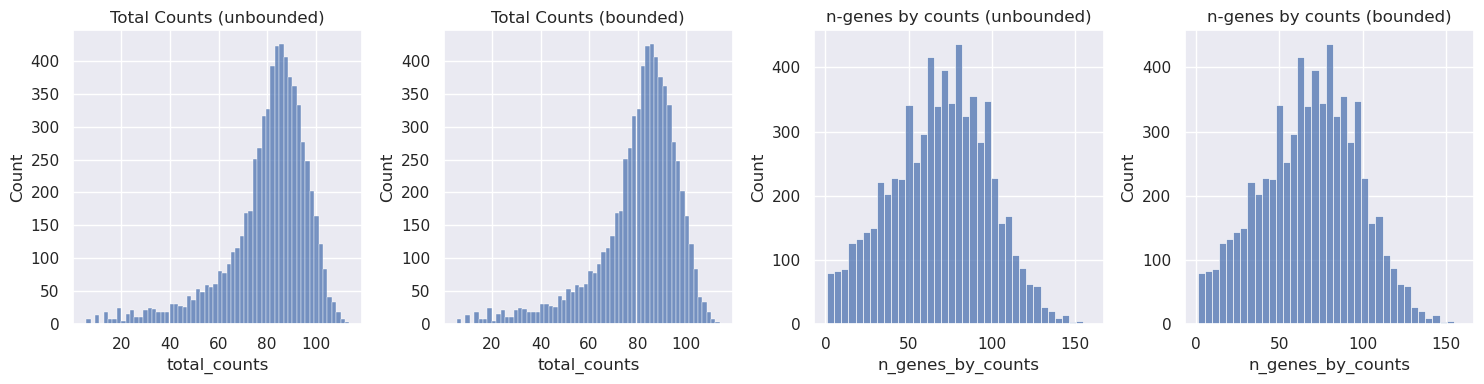

In [207]:


# ---------------------------------------------------------------------------- #
#                          CALCULATE SCANPY QC METRICS                         #
# ---------------------------------------------------------------------------- #

## Calculate some basic scanpy quality metric for plotting
adata.var_names_make_unique() # This ensure all probe names are unique
sc.pp.calculate_qc_metrics(adata, 
                           log1p=True, 
                           inplace=True,
                           percent_top=[10,20]
                           )


from banksy_utils.plot_utils import plot_qc_hist, plot_cell_positions
# bin options for fomratting histograms
# Here, we set 'auto' for 1st figure, 'auto' bins for 2nd figure and so on
hist_bin_options = ['auto', 'auto', 'auto', 'auto']

plot_qc_hist(adata, 
         total_counts_cutoff = 200, # for visualization
         n_genes_high_cutoff = 1000, # for visualization
         n_genes_low_cutoff = 0, # for visualization
         bin_options = hist_bin_options)

plt.savefig(os.path.join(qc_path, f"banksy_counts_and_genes_plot_{dataset_name}.png"), dpi =300, bbox_inches='tight')
plt.show()




In [208]:
## Check to compare nCount_Xenium, adata.X and adata.layers["counts"]
## nCount_Xenium and adata.layers["counts"] represent raw counts before any normalisation/transformation
## adata.X contains log-transformed and scanpy.pp.normalize_total() normalised counts
import pandas as pd

cell_slice = slice(0, 10)

X_sums = np.asarray(
    adata.X[cell_slice, :].sum(axis=1)
).ravel()

count_layer_sums = np.asarray(
    adata.layers["counts"][cell_slice, :].sum(axis=1)
).ravel()

comparison = pd.DataFrame(
    {
        "nCount_Xenium": adata.obs["nCount_Xenium"].iloc[cell_slice],
        "X_sum": X_sums,
        "counts_layer_sum": count_layer_sums,
    },
    index=adata.obs_names[cell_slice],
)

comparison

,nCount_Xenium,X_sum,counts_layer_sum
aaabjldc-1,765,75.570930,765.0
aaaenhao-1,771,95.937561,771.0
aaamkopm-1,287,78.399803,287.0
aaamomnk-1,270,76.257263,270.0
aabbmchc-1,60,64.604218,60.0
aablipbe-1,131,86.169106,131.0
aabmjlel-1,211,100.946815,211.0
aacjkkgn-1,127,88.767799,127.0
aackhcpc-1,142,64.512482,142.0
aacnfmpe-1,257,69.757202,257.0


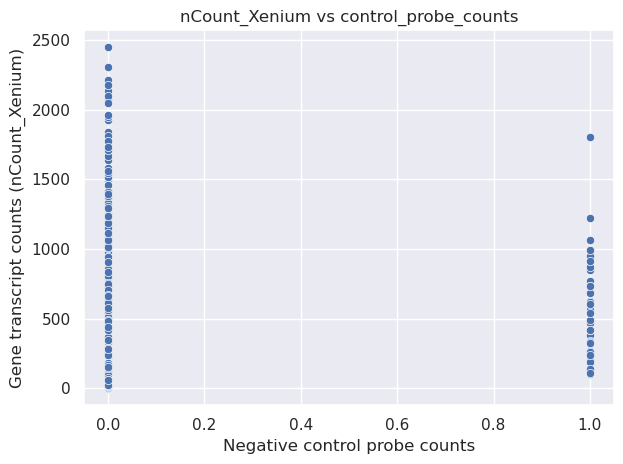

Saving Gene_transcript_counts_vs_Negative_Control_probes_counts_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [209]:
# ---------------------------------------------------------------------------- #
#                   FILTER 1 - NEGATIVE CONTROL PROBE FILTER                   #
# ---------------------------------------------------------------------------- #

## Check to compare nCount_Xenium, adata.X and adata.layers["counts"]
## nCount_Xenium and adata.layers["counts"] represent raw counts before any normalisation/transformation
## adata.X contains log-transformed and scanpy.pp.normalize_total() normalised counts
import pandas as pd

cell_slice = slice(0, 10)

X_sums = np.asarray(
    adata.X[cell_slice, :].sum(axis=1)
).ravel()

count_layer_sums = np.asarray(
    adata.layers["counts"][cell_slice, :].sum(axis=1)
).ravel()

comparison = pd.DataFrame(
    {
        "nCount_Xenium": adata.obs["nCount_Xenium"].iloc[cell_slice],
        "X_sum": X_sums,
        "counts_layer_sum": count_layer_sums,
    },
    index=adata.obs_names[cell_slice],
)

comparison

# ------------------- nCount_Xenium vs control_probe_counts ------------------ #

sns.set_theme(style="darkgrid")

sns.scatterplot(
    data = adata.obs,
    x= "control_probe_counts",
    y= "nCount_Xenium"
    )

plt.title("nCount_Xenium vs control_probe_counts")
plt.ylabel("Gene transcript counts (nCount_Xenium)")
plt.xlabel("Negative control probe counts")

plt.tight_layout()
# Save the figure
plt.savefig(
    os.path.join(qc_path, f"Gene_transcript_counts_vs_Negative_Control_probes_counts_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Saving Gene_transcript_counts_vs_Negative_Control_probes_counts_{dataset_name}.png to {qc_path}")


In [210]:
## Summary of number of features
# features = pd.read_csv(
#     os.path.join(raw_path, "features", f"{dataset_name}", "features.tsv.gz"),
#     sep="\t",
#     header=None
# )
# 
# features.columns = ["feature_id", "feature_name", "feature_type"]
# features["feature_type"].value_counts()
# features
# 
# ## Print the number of control probes
# negative_control_probes = features.loc[
#     features["feature_type"]
#     .astype(str)
#     .str.contains("negative.*control.*probe", case=False, regex=True),
#     "feature_name"
# ].sort_values()
# 
# print(f"Number of negative-control probes: {len(negative_control_probes)}")
# print(negative_control_probes.tolist())

44 / 6,760 cells (0.65%) have >=1 negative control probe count


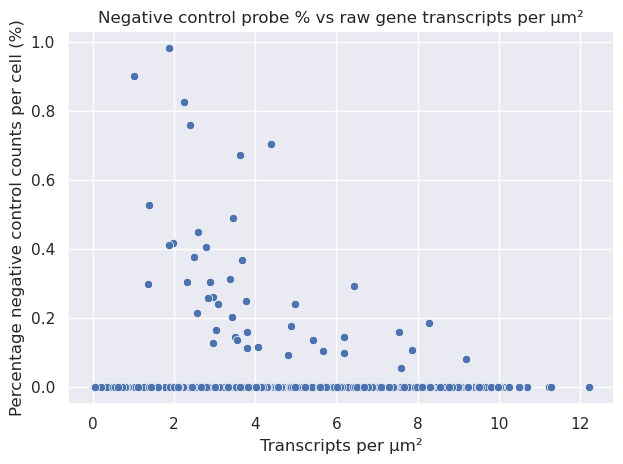

Saving Negative_Control_%_vs_Transcript_Density_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [211]:
## Create a mask for cells with at least 1 negative probe counts
neg_mask = adata.obs["control_probe_counts"] >= 1

n_neg_cells = neg_mask.sum()
n_total_cells = adata.n_obs

percent_neg_cells = n_neg_cells / n_total_cells * 100

print(f"{n_neg_cells:,} / {n_total_cells:,} cells ({percent_neg_cells:.2f}%) have >=1 negative control probe count")

## Calculate the percentage of negative controls per total transcripts for each cell
adata.obs["neg_probe_pct_of_gene_plus_neg_probe"] = (adata.obs["control_probe_counts"] / (adata.obs["nCount_Xenium"] + adata.obs["control_probe_counts"])) * 100

## Calculate the transcripts detected per um^2 of cell area
adata.obs["gene_transcripts_per_um2"] = ((adata.obs["nCount_Xenium"]) / adata.obs["cell_area"])

#data.obs["neg_probe_pct_of_gene_plus_neg_probe"] = adata.obs["neg_probe_pct_of_gene_plus_neg_probe"]
#adata.obs["gene_transcripts_per_um2"] = adata.obs["gene_transcripts_per_um2"]


## percentage of negative controls vs transcripts detected per um^2

sns.set_theme(style="darkgrid")

sns.scatterplot(
    data = adata.obs,
    x= "gene_transcripts_per_um2",
    y= "neg_probe_pct_of_gene_plus_neg_probe"    
    )

plt.title("Negative control probe % vs raw gene transcripts per µm²")
plt.ylabel("Percentage negative control counts per cell (%)")
plt.xlabel("Transcripts per µm²")

plt.tight_layout()
# Save the figure
plt.savefig(
    os.path.join(qc_path, f"Negative_Control_%_vs_Transcript_Density_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Saving Negative_Control_%_vs_Transcript_Density_{dataset_name}.png to {qc_path}")


In [212]:
## Read in transcript parquet to get raw negative control probe counts
tx = pd.read_parquet(os.path.join(raw_path, "transcript_parquet", f"{dataset_name}"))
tx["codeword_category"].value_counts()

##subset transcripts tx to only those cells present in the adata object
adata_cells = set(adata.obs_names.astype(str))
tx["cell_id"] = tx["cell_id"].astype(str)

tx_subset = tx[tx["cell_id"].isin(adata_cells)].copy()

tx_subset.to_parquet(os.path.join(output_path,"transcripts_subset_to_adatat_clean_cells.parquet"))

print("Original transcripts:", len(tx))
print("Subset transcripts:", len(tx_subset))
print("Unique transcript cell IDs:", tx_subset["cell_id"].nunique())
print("AnnData cells:", adata.n_obs)

Original transcripts: 2975663
Subset transcripts: 2440683
Unique transcript cell IDs: 6760
AnnData cells: 6760


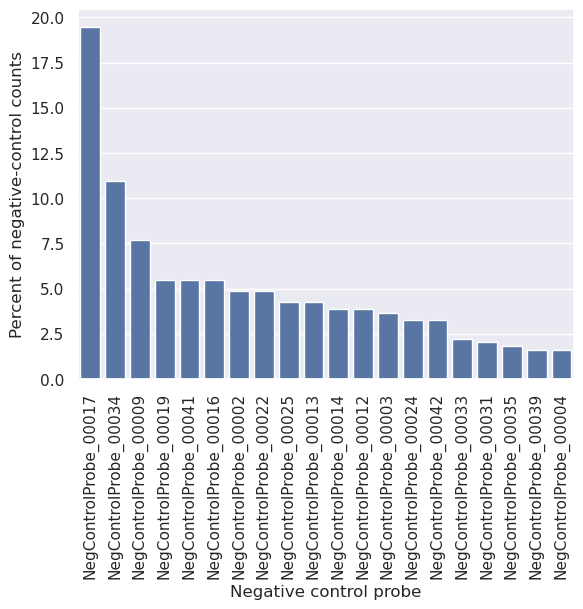

Percentage_negative_control_probe_in_total_negative_probe_counts_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [213]:
## Subset transcripts parquet to negative probe transcripts
neg_tx = tx_subset[tx_subset["codeword_category"] == "negative_control_probe"]

neg_probes = sorted(
    neg_tx["feature_name"].dropna().unique(),
    key=lambda x: int(x.split("_")[-1])
)

neg_probes

# - Percentage of each negative control probe in total negative probe counts - #
neg_probe_counts = neg_tx["feature_name"].value_counts()

neg_probe_summary = (
    neg_probe_counts
    .rename_axis("negative_control_probe")
    .reset_index(name="counts")
)

neg_probe_summary["percent_of_negative_control_counts"] = (
    neg_probe_summary["counts"] / neg_probe_summary["counts"].sum() * 100
)

sns.barplot(
    data=neg_probe_summary,
    x="negative_control_probe",
    y="percent_of_negative_control_counts"
)

plt.ylabel("Percent of negative-control counts")
plt.xlabel("Negative control probe")
plt.xticks(rotation=90)

plt.savefig(
    os.path.join(qc_path, f"Percentage_negative_control_probe_in_total_negative_probe_counts_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Percentage_negative_control_probe_in_total_negative_probe_counts_{dataset_name}.png to {qc_path}")  

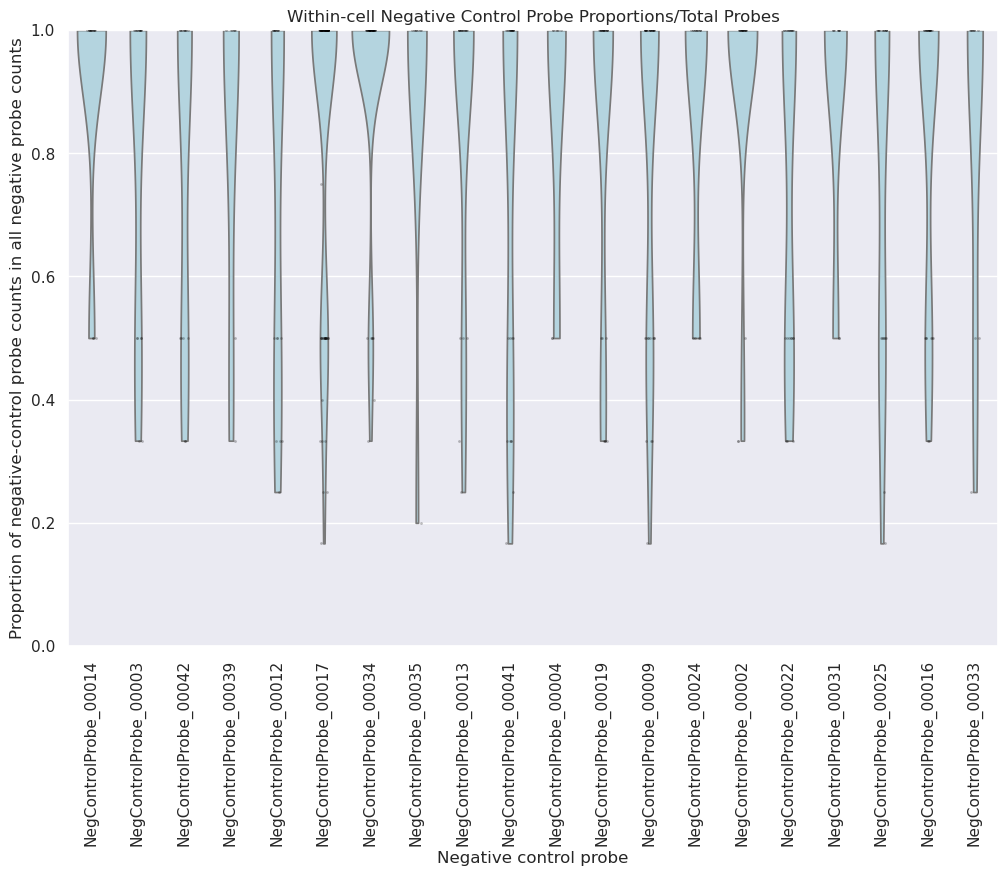

Percentage_negative_control_probe_in_total_negative_probe_counts_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [214]:
# ------------------- Negative control probe count per cell ------------------ #

# Calculate, for each cell, what proportion of its negative-control signal
# comes from each negative-control probe.

neg_tx_assigned = neg_tx[neg_tx["cell_id"] != "UNASSIGNED"].copy()

probe_counts = (
    neg_tx_assigned
    .groupby(["cell_id", "feature_name"])
    .size()
    .reset_index(name="probe_count")
)

probe_counts["total_neg_counts_per_cell"] = (
    probe_counts
    .groupby("cell_id")["probe_count"]
    .transform("sum")
)

probe_counts["probe_proportion_within_cell"] = (
    (probe_counts["probe_count"] / probe_counts["total_neg_counts_per_cell"])
)

probe_counts.head()

## Negative probe proportion within cell
probe_counts["probe_proportion_within_cell"].min(), probe_counts["probe_proportion_within_cell"].max()

# ------------ Negative control probe count per cell violin plots ------------ #

plt.figure(figsize=(12, 8))

sns.violinplot(
    data=probe_counts,
    x="feature_name",
    y="probe_proportion_within_cell",
    cut=0,
    inner=None,
    color="lightblue"
)

sns.stripplot(
    data=probe_counts,
    x="feature_name",
    y="probe_proportion_within_cell",
    color="black",
    alpha=0.25,
    size=2,
    jitter=True
)

plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.ylabel("Proportion of negative-control probe counts in all negative probe counts")
plt.xlabel("Negative control probe")
plt.title("Within-cell Negative Control Probe Proportions/Total Probes")

plt.savefig(
    os.path.join(qc_path, f"Percentage_negative_control_probe_in_total_negative_probe_counts_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Percentage_negative_control_probe_in_total_negative_probe_counts_{dataset_name}.png to {qc_path}")    

In [215]:
# ---------------------------------------------------------------------------- #
#                          NEGATIVE CONTROL PROBE MASK                         #
# ---------------------------------------------------------------------------- #

# Mask cells with at least 1 or more negative control probe counts
adata.obs["has_negative_control_probe_counts"] = (
    adata.obs["control_probe_counts"] >= 1
)

# Create a category to colour plots
adata.obs["negative_control_probe_greater_equal_1_cat"] = (
    adata.obs["has_negative_control_probe_counts"]
    .map({True: "Has negative control", False: "No negative control"})
    .astype("category")
)



# ----------------------------------- TEST ----------------------------------- #

official_neg_cell_ids = set(
    adata.obs.index[adata.obs["has_negative_control_probe_counts"]].astype(str)
)

# Keep transcript-level probe identities only for cells positive by control_probe_counts.
neg_tx_official = neg_tx_assigned[
    neg_tx_assigned["cell_id"].astype(str).isin(official_neg_cell_ids)
].copy()

probe_counts_official = (
    neg_tx_official
    .groupby(["cell_id", "feature_name"])
    .size()
    .reset_index(name="probe_count")
)

probe_count_matrix_official = (
    probe_counts_official
    .pivot(index="cell_id", columns="feature_name", values="probe_count")
    .reindex(adata.obs_names.astype(str))
    .fillna(0)
)

probe_count_matrix_official.index = adata.obs_names
probe_order_official = (
    probe_count_matrix_official
    .sum(axis=0)
    .sort_values(ascending=False)
    .index
    .tolist()
)

Saved figure to: data/xenium/output/vbct/QC_testing/CK_skin_res/tissue_spatial_scatter_min_negative_control_probe_greater_equal_1_cat_CK_skin_res.png


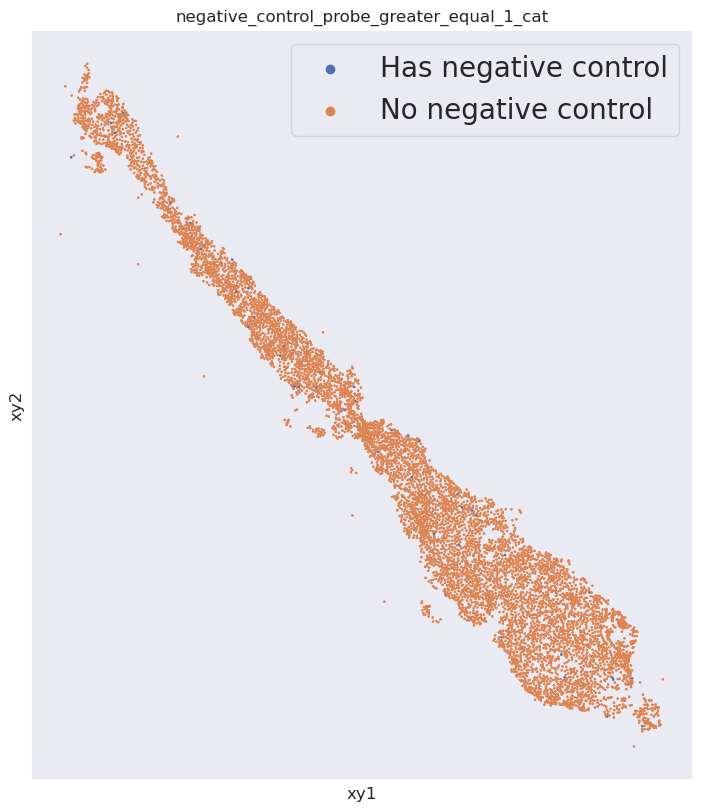

In [216]:
# ------- Plot location of cell with >= 1 negative control probe count ------- #

## Tissue plot of cells with minimum number of transcripts
plot_qc_spatial_tissue(
    data = adata,
    qc_metric = "negative_control_probe_greater_equal_1_cat",
    sample_name = dataset_name
)

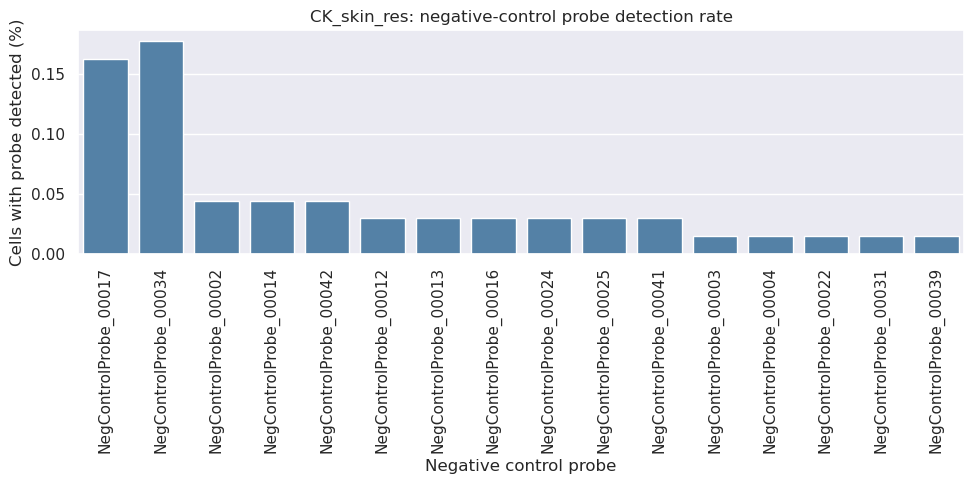

Negative_control_probe_detection_rate_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [217]:
# ---------------------------------------------------------------------------- #
#          PLOT 2 - NEGATIVE CONTROL PROBE DETECTION RATE BAR PLOT             #
# ---------------------------------------------------------------------------- #

neg_probe_detection_rate = (
    probe_count_matrix_official.gt(0).sum(axis=0) / adata.n_obs * 100
).rename_axis("negative_control_probe").reset_index(name="percent_cells_detected")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=neg_probe_detection_rate,
    x="negative_control_probe",
    y="percent_cells_detected",
    order=probe_order_official,
    color="steelblue"
)

plt.ylabel("Cells with probe detected (%)")
plt.xlabel("Negative control probe")
plt.title(f"{dataset_name}: negative-control probe detection rate")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    os.path.join(qc_path, f"Negative_control_probe_detection_rate_{dataset_name}.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(f"Negative_control_probe_detection_rate_{dataset_name}.png to {qc_path}")

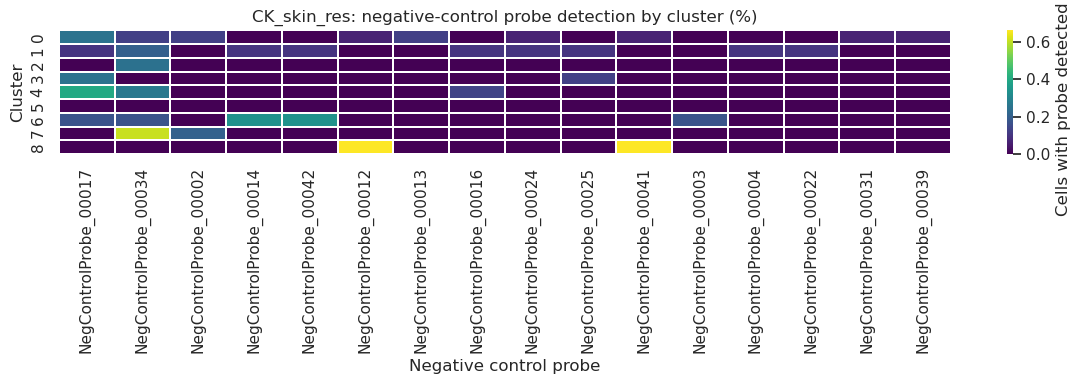

Cluster_by_negative_control_probe_detection_heatmap_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [218]:
# ---------------------------------------------------------------------------- #
#              PLOT 4 - CLUSTER BY NEGATIVE CONTROL PROBE HEATMAP              #
# ---------------------------------------------------------------------------- #

cluster_plot_col = cluster_ann_col if cluster_ann_col in adata.obs.columns else cluster_col

cluster_probe_detection = probe_count_matrix_official.gt(0).copy()
cluster_probe_detection[cluster_plot_col] = adata.obs[cluster_plot_col].astype(str).values

cluster_probe_detection_percent = (
    cluster_probe_detection
    .groupby(cluster_plot_col)[probe_order_official]
    .mean()
    * 100
)

plt.figure(figsize=(12, max(4, 0.35 * cluster_probe_detection_percent.shape[0])))

sns.heatmap(
    cluster_probe_detection_percent,
    cmap="viridis",
    linewidths=0.2,
    cbar_kws={"label": "Cells with probe detected (%)"}
)

plt.ylabel("Cluster")
plt.xlabel("Negative control probe")
plt.title(f"{dataset_name}: negative-control probe detection by cluster (%)")
plt.tight_layout()

plt.savefig(
    os.path.join(qc_path, f"Cluster_by_negative_control_probe_detection_heatmap_{dataset_name}.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(f"Cluster_by_negative_control_probe_detection_heatmap_{dataset_name}.png to {qc_path}")




In [76]:
negative_probe_vars = [
    v for v in adata.var_names
    if str(v).startswith("NegControlProbe_")
]

negative_probe_vars

[]

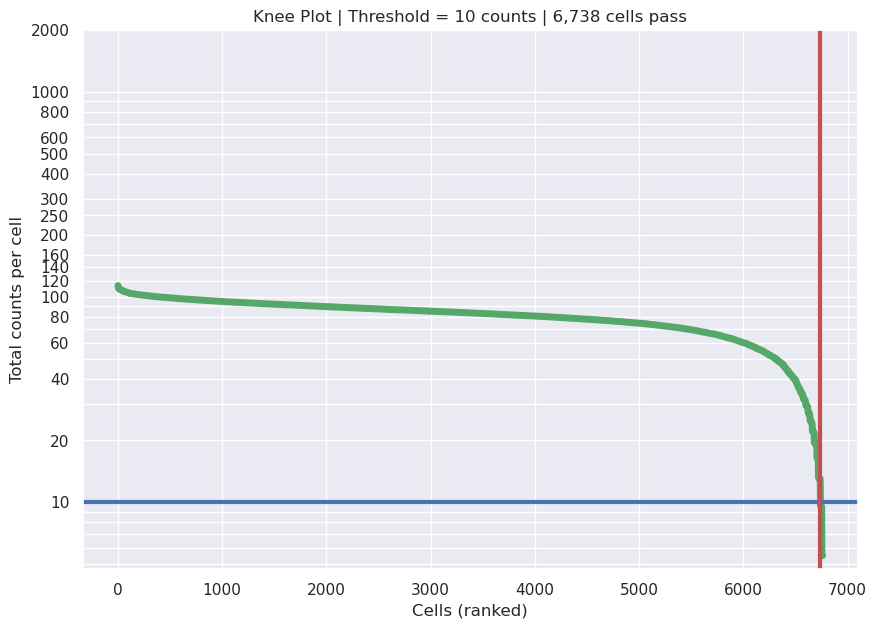

Cells passing threshold of 10 counts: 6,738 / 6,760 (99.7%)


In [21]:
# ---------------------------------------------------------------------------- #
#                FILTER 2 - MINIMUM NUMBER OF TRANSCRIPTS FILTER               #
# ---------------------------------------------------------------------------- #

### Plot knee plot (log10 transcripts per cell)
## Knee plot code adapted from https://pachterlab.github.io/kallistobustools/tutorials/kb_getting_started/python/kb_intro_2_python/

# ------------------- Set the minimum transcript threshold ------------------- #
threshold = 10
knee = np.sort((np.array(adata.X.sum(axis=1))).flatten())[::-1]

## Plot the knee plot
cell_set = np.arange(len(knee))
num_cells = (knee > threshold).sum()
fig, ax = plt.subplots(figsize=(10, 7))

ax.semilogy(knee, linewidth =5, color="g")
ax.axhline(y=threshold, linewidth=3, color="b")
ax.axvline(x=num_cells, linewidth=3, color="r")

ax.set_xlabel("Cells (ranked)")
ax.set_ylabel("Total counts per cell")

ax.set_yticks([10, 20, 40, 60, 80, 100, 120, 140, 160, 200, 250, 300, 400, 500, 600, 800, 1000, 2000])
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

plt.grid(True, which="both")
plt.title(f"Knee Plot | Threshold = {threshold} counts | {num_cells:,} cells pass")
plt.savefig(os.path.join(qc_path, f"transcript_knee_plot_{dataset_name}.png"), dpi =300, bbox_inches='tight')
plt.show()

print(f"Cells passing threshold of {threshold} counts: {num_cells:,} / {len(knee):,} ({num_cells/len(knee)*100:.1f}%)")




In [22]:
# ---------------- Apply the minimum transcripts per cell mask --------------- #

## Apply a mask to retrieve cells that don't pass the filter
mask = adata.obs['nCount_Xenium'] <= threshold

# Turn the masked cells into a data frame
mask.to_frame()
mask_cells = mask.reset_index()
mask_cells = mask_cells.rename(columns={"index":"cell_id", "nCount_Xenium" : "min_trans_passed"})

# # Filter for the poor cells and keep these ids for future plotting
# min_trans_filter_failed = mask_cells[mask_cells['min_trans_passed']]

# Put results for the cells passing the threshold into the object directly
adata.obs['min_trans_passed'] = adata.obs['nCount_Xenium'] > threshold #True = passed




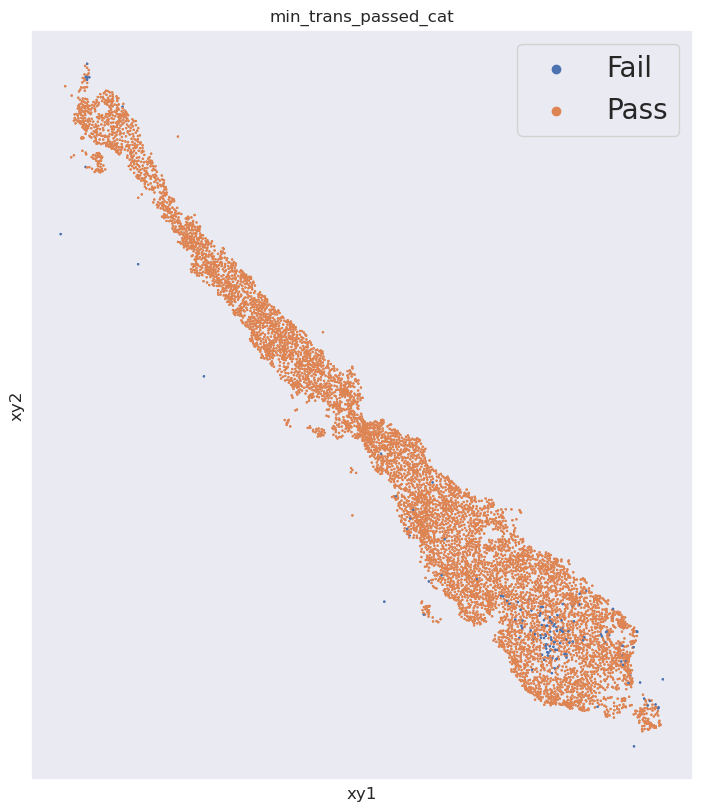

Saving tissue_spatial_scatter_min_trans_passed_cat_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [23]:
# ------------------- Plot location of poor cells on tissue ------------------ #
adata.obs["min_trans_passed_cat"] = adata.obs["min_trans_passed"].map({True: "Pass", False: "Fail"}).astype("category")

## Tissue plot of cells with minimum number of transcripts
plot_qc_spatial_tissue(
    data = adata,
    qc_metric = "min_trans_passed_cat",
    sample_name = dataset_name
)

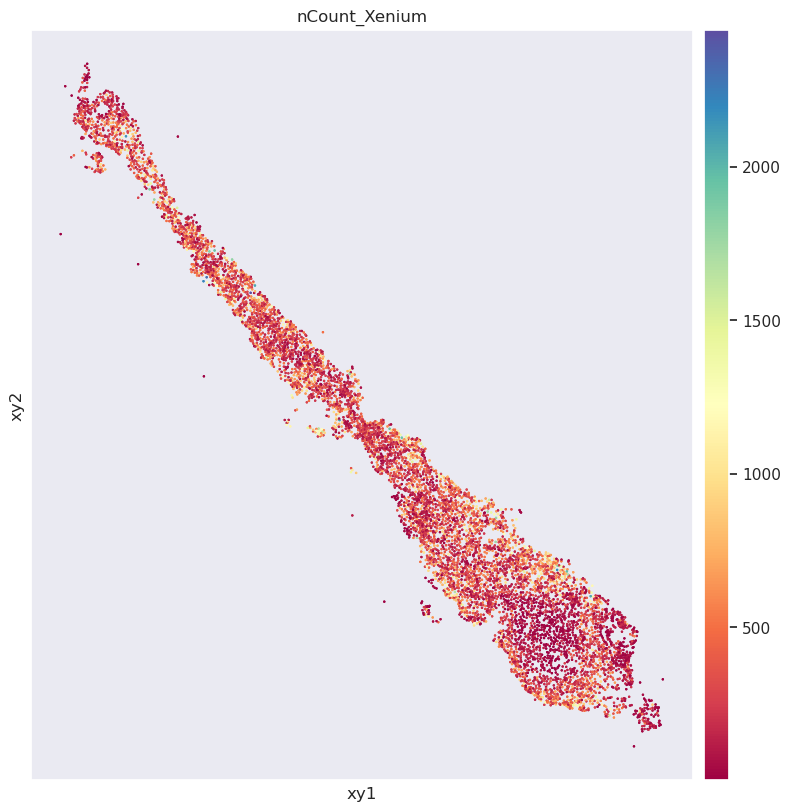

In [24]:
# -------------- Plot of total transripts per cell across sample ------------- #
# gist_stern, dynamic vmax threshold
with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="nCount_Xenium",
        shape=None,
        size=2,
        img=False,
        vmax = adata.obs['nCount_Xenium'].max(),
        cmap="Spectral"
    )

## Save the figure
plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_transcripts_qc_dynamic_range_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 


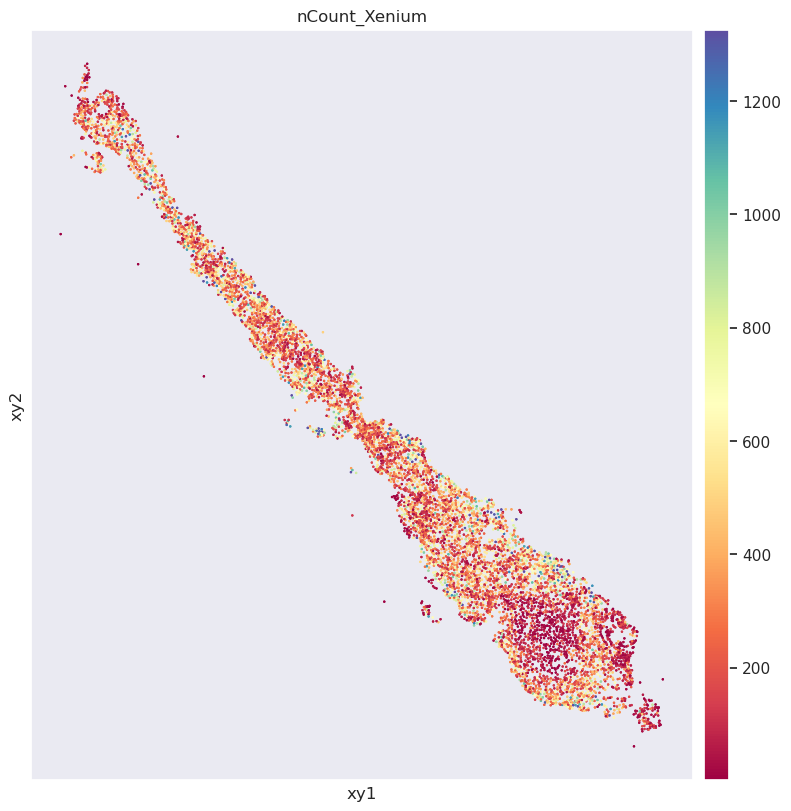

In [25]:
# -------------- Plot of total transripts per cell across sample ------------- #
# vmax set to the 99th percentile of transcript counts
with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="nCount_Xenium",
        shape=None,
        size=2,
        img=False,
        vmax = adata.obs['nCount_Xenium'].quantile(0.99),
        #cmap="gist_stern"
        #cmap="gist_rainbow"
        #cmap="rainbow"
        cmap="Spectral"
    )

plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_transcripts_qc_quantile_99_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 




In [26]:
# ---------------------------------------------------------------------------- #
#                         EXPORT ADATA.X MATRIX TO .CSV                        #
# ---------------------------------------------------------------------------- #

## Convert the the whole adata.X into a matrix and export to .csv
pd.DataFrame(
    adata.X.toarray(),  # convert sparse matrix to dense
    index=adata.obs_names, 
    columns=adata.var_names
).to_csv(os.path.join(qc_path, f"adata_X_inspection_{dataset_name}.csv"))

obs= adata.obs
obs.to_csv(os.path.join(qc_path, f"obs_{dataset_name}.csv"))




In [27]:
# ---------------------------------------------------------------------------- #
#                             HIGH COUNT GENES PLOT                            #
# ---------------------------------------------------------------------------- #

# ----------- Calculate the sum of a genes counts across all cells ----------- #
## Sort the adata.obs by total_counts to see which genes have exceedingly high counts
obs = adata.obs
obs.sort_values(by=["transcript_counts"], ascending=False)
obs.to_csv(os.path.join(qc_path, f"obs_{dataset_name}.csv"))
print("All files saved to:", qc_path)


All files saved to: data/xenium/output/vbct/QC_testing/CK_skin_res


In [28]:


# # ----------- Calculate the total counts for genes across all cells ---------- #
# adata_X = pd.DataFrame(
#     adata.X.toarray(),
#     index=adata.obs_names,
#     columns=adata.var_names
# )

# gene_total_object = adata_X.sum(axis=0)


# top_genes_object = gene_total_object.sort_values(ascending=False).reset_index()
# top_genes_object.columns = ['gene', 'total_counts']
# top_genes_object.to_csv(os.path.join(qc_path, f"gene_counts_across_all_cells_{dataset_name}_test.csv"))




In [29]:


# # --------------------------- Plot the top 50 genes -------------------------- #
# top_genes_object = top_genes_object.iloc[0:51]

# plt.figure(figsize=(25, 5))
# plt.scatter(top_genes_object['gene'], top_genes_object['total_counts'])
# plt.xticks(rotation=90)
# plt.tight_layout()

# plt.savefig(
#     os.path.join(qc_path, f"top_50_genes_by_counts_{dataset_name}.png"),
#     dpi=300,
#     bbox_inches='tight'
#     )




In [30]:
# ---------------------------------------------------------------------------- #
#                FILTER 3 - MAXIMUM NUMBER OF TRANSCRIPTS FILTER               #
# ---------------------------------------------------------------------------- #

# ---- Maximum transcripts per cell mask for cells with top 2% transcripts --- #
raw_counts = adata.obs['nCount_Xenium']
quantile = np.quantile(raw_counts, 0.98)
quantile_masked_cells = raw_counts >= quantile
quantile_masked_cells = quantile_masked_cells.reset_index()
max_trans_threshold_passed = quantile_masked_cells.rename(columns={"nCount_Xenium" : "max_transcripts_passed"})
max_trans_threshold_passed = max_trans_threshold_passed.set_index("index")
adata.obs['max_trans_threshold_passed'] = max_trans_threshold_passed['max_transcripts_passed']




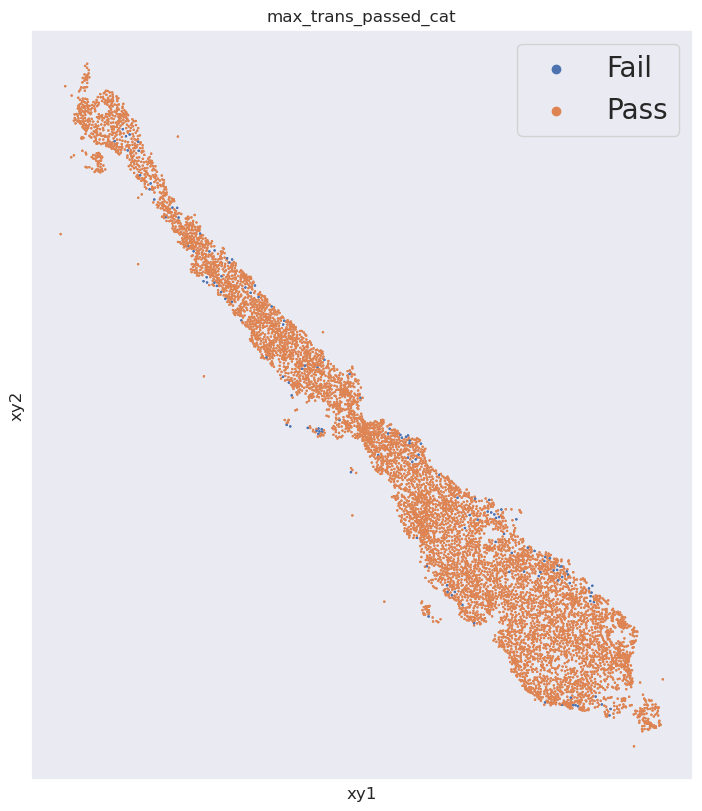

Saving tissue_spatial_scatter_max_trans_passed_cat_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [31]:
# ------------------- Plot location of poor cells on tissue ------------------ #
adata.obs["max_trans_passed_cat"] = adata.obs["max_trans_threshold_passed"].map({True: "Fail", False: "Pass"}).astype("category")

## Tissue plot of cells with max transcripts threshold 
plot_qc_spatial_tissue(
    data = adata,
    qc_metric = "max_trans_passed_cat",
    sample_name = dataset_name
)

In [32]:

# ---------------------------------------------------------------------------- #
#                  USE CLEAN CLUSTERED ANNDATA FOR CLUSTER QC                  #
# ---------------------------------------------------------------------------- #

## The clean object already contains BANKSY cluster labels in .obs, so this
## script does not read old BANKSY spatial objects or rebuild clusters from saved BANKSY outputs.
adata = adata
adata.obs[cluster_col] = adata.obs[cluster_col].astype(str)

if new_labels:
    adata.obs[cluster_ann_col] = adata.obs[cluster_col].map(new_labels)
    adata.obs[cluster_ann_col] = adata.obs[cluster_ann_col].fillna(adata.obs[cluster_col]).astype("category")
else:
    adata.obs[cluster_ann_col] = adata.obs[cluster_col].astype("category")




In [33]:
# ---------------------------------------------------------------------------- #
#                         FILTER 4 - CELL AREA FILTERS                         #
# ---------------------------------------------------------------------------- #

# ------------------------- Top 1% cells by cell area ------------------------ #
cell_area = adata.obs["cell_area"]
area_quantile = np.quantile(cell_area, 0.99)
area_quantile_mask = cell_area >= area_quantile
adata.obs["max_area_threshold_99"] = area_quantile_mask

# Create a category to colour plots
adata.obs["max_area_threshold_99_cat"] = (
    adata.obs["max_area_threshold_99"]
    .map({True: "Fail", False: "Pass"})
    .astype("category")
)

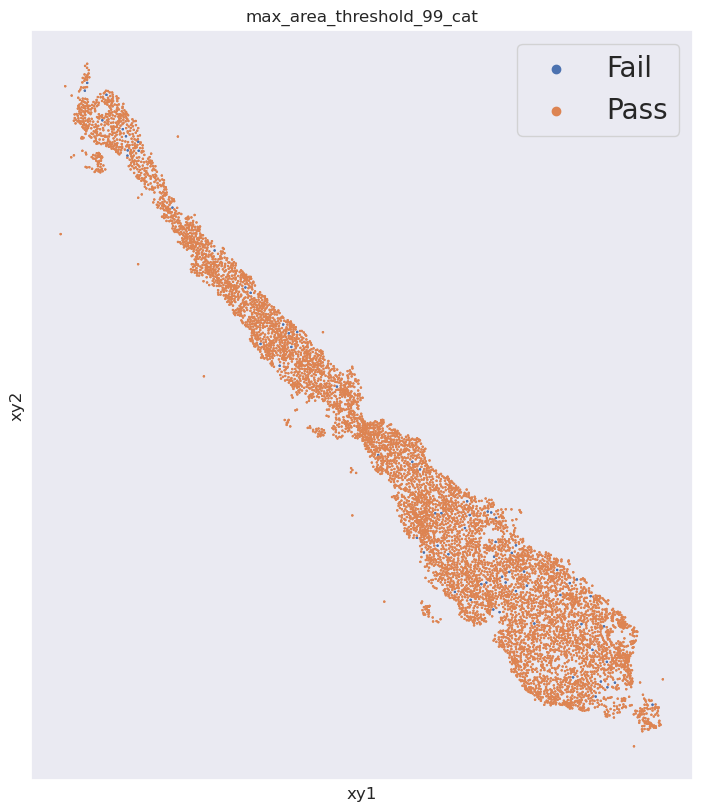

tissue_spatial_scatter_max_area_threshold_99_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [34]:
# Plot the cell with negative controls on the tissue spatial plot
with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="max_area_threshold_99_cat",
        shape=None,
        size=2,
        img=False
    )
    plt.legend(fontsize=20)

    plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_max_area_threshold_99_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"tissue_spatial_scatter_max_area_threshold_99_{dataset_name}.png to {qc_path}") 

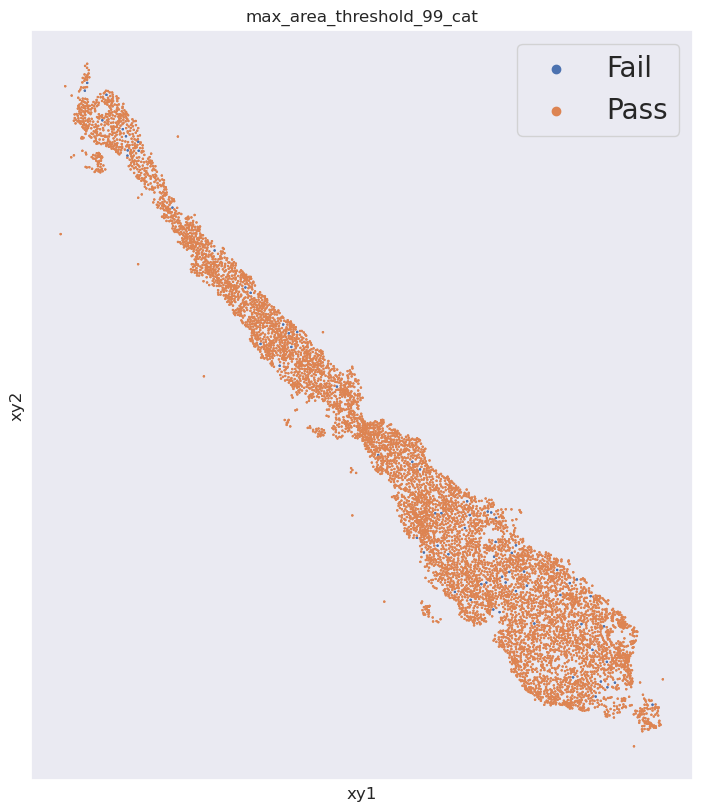

Saving tissue_spatial_scatter_max_area_threshold_99_cat_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [35]:

# Create a category to colour plots
adata.obs["max_area_threshold_99_cat"] = (
    adata.obs["max_area_threshold_99"]
    .map({True: "Fail", False: "Pass"})
    .astype("category")
)

## Tissue plot of cells with max transcripts threshold 
plot_qc_spatial_tissue(
    data = adata,
    qc_metric = "max_area_threshold_99_cat",
    sample_name = dataset_name
)

In [36]:
# ------------------------- Top 2% cells by cell area ------------------------ #

cell_area = adata.obs["cell_area"]
area_quantile = np.quantile(cell_area, 0.98)
area_quantile_mask = cell_area >= area_quantile
adata.obs["max_area_threshold_98"] = area_quantile_mask

# Create a category to colour plots
adata.obs["max_area_threshold_98_cat"] = (
    adata.obs["max_area_threshold_98"]
    .map({True: "Fail", False: "Pass"})
    .astype("category")
)

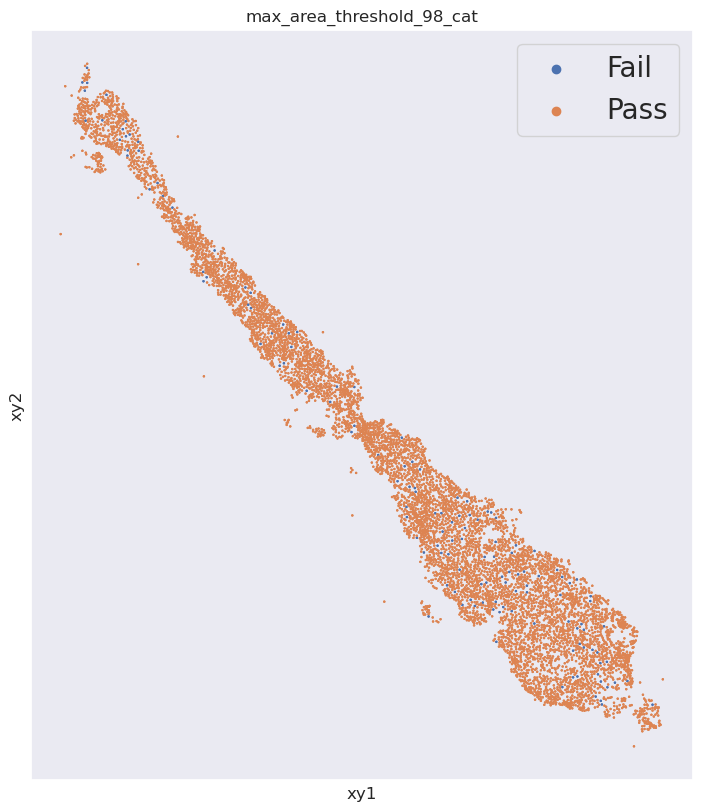

Saving tissue_spatial_scatter_max_area_threshold_98_cat_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [37]:
## Tissue plot of cells with max transcripts threshold 
plot_qc_spatial_tissue(
    data = adata,
    qc_metric = "max_area_threshold_98_cat",
    sample_name = dataset_name
)

In [38]:
# ----------------------- Bottom 1% cells by cell area ----------------------- #
cell_area = adata.obs["cell_area"]
area_quantile = np.quantile(cell_area, 0.01)
area_quantile_mask = cell_area <= area_quantile
adata.obs["min_area_threshold_1"] = area_quantile_mask

# Create a category to colour plots
adata.obs["min_area_threshold_1_cat"] = (
    adata.obs["min_area_threshold_1"]
    .map({True: "Fail", False: "Pass"})
    .astype("category")
)

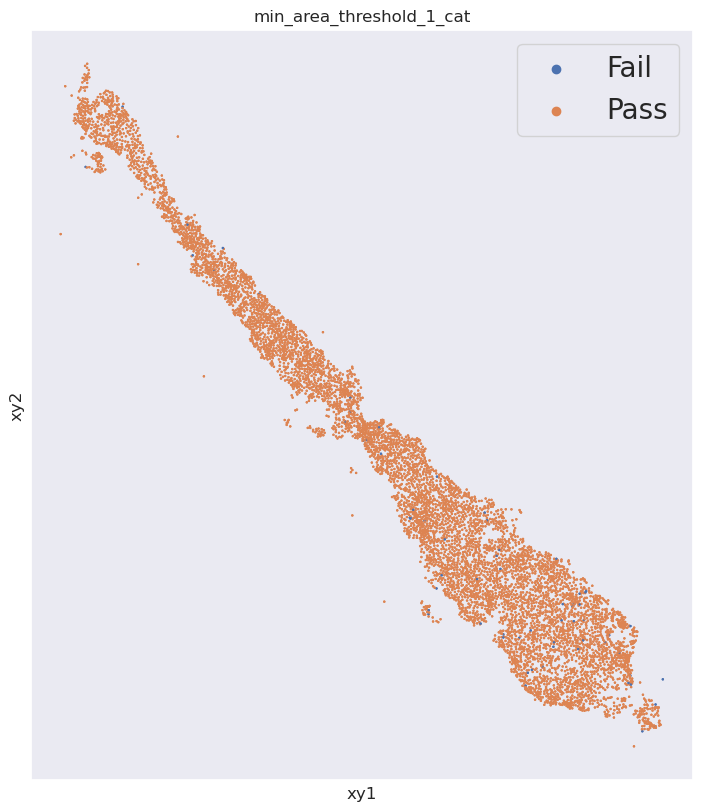

Saving tissue_spatial_scatter_min_area_threshold_1_cat_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [39]:
## Tissue plot of cells with max transcripts threshold 
plot_qc_spatial_tissue(
    data = adata,
    qc_metric = "min_area_threshold_1_cat",
    sample_name = dataset_name
)

In [40]:
# ----------------------- Bottom 2% cells by cell area ----------------------- #
cell_area = adata.obs["cell_area"]
area_quantile = np.quantile(cell_area, 0.02)
area_quantile_mask = cell_area <= area_quantile
adata.obs["min_area_threshold_2"] = area_quantile_mask

# Create a category to colour plots
adata.obs["min_area_threshold_2_cat"] = (
    adata.obs["min_area_threshold_2"]
    .map({True: "Fail", False: "Pass"})
    .astype("category")
)

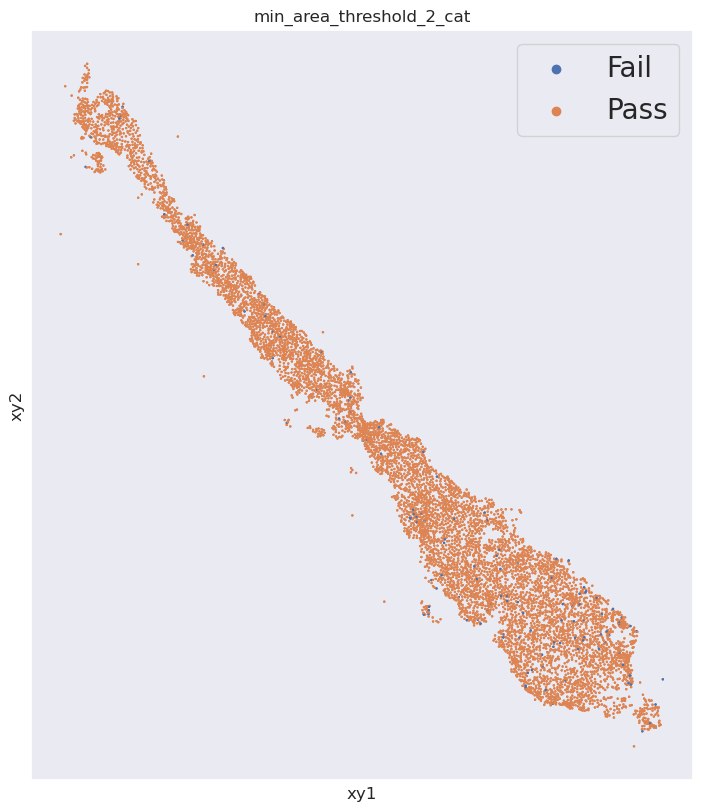

Saving tissue_spatial_scatter_min_area_threshold_2_cat_CK_skin_res.png to data/xenium/output/vbct/QC_testing/CK_skin_res


In [41]:
## Tissue plot of cells with 
plot_qc_spatial_tissue(
    data = adata,
    qc_metric = "min_area_threshold_2_cat",
    sample_name = dataset_name
)

In [42]:
# ---------------------------------------------------------------------------- #
#                     CLUSTERING RESOLUTION LEVEL ANALYSIS                     #
# ---------------------------------------------------------------------------- #

In [ ]:
# ------------- Plot the per cluster plots coloured by qc metrics ------------ #

cluster_qc_violin_plots = [
    ("negative_control_probe_greater_equal_1_cat", "Negative-control probe count >= 1"),
    ("min_trans_passed_cat", "Minimum transcript threshold"),
    ("max_trans_passed_cat", "Top 2% transcript count threshold"),
    ("max_area_threshold_98_cat", "Top 2% of cells by cell area"),
    ("max_area_threshold_99_cat", "Top 1% of cells by cell area"),
    ("min_area_threshold_1_cat", "Bottom 1% of cells by cell area"),
    ("min_area_threshold_2_cat", "Bottom 2% of cells by cell area"),
]

filter_stage = "pre_filter"

# Plot raw BANKSY clusters for every available resolution. These plots are for
# QC inspection across clustering resolutions, so they intentionally use raw
# cluster IDs rather than the manually annotated column for one resolution.
for res in res_label_list:
    cluster_col_for_res = (
        f"labels_{nbr_weight_decay}_pc{pc_label}_nc{lambda_label}_r{float(res):.2f}"
    )

    if cluster_col_for_res not in adata.obs.columns:
        print(f"Skipping missing cluster column: {cluster_col_for_res}")
        continue

    for qc_metric, qc_title in cluster_qc_violin_plots:
        if qc_metric not in adata.obs.columns:
            print(f"Skipping missing QC metric: {qc_metric}")
            continue

        cluster_qc_violin(
            data=adata,
            cluster_col=cluster_col_for_res,
            qc_metric=qc_metric,
            sample_name=dataset_name,
            qc_title=qc_title,
            output_path=qc_violin_path,
            filename_prefix=f"{filter_stage}_cluster_qc_violin",
            filename_tag=f"r{res}",
            title_tag=f"resolution {float(res):.2f}",
        )

# Keep annotated plots separate so pre-filter and post-filter results can be
# compared back to the manually interpreted clustering resolution.
if cluster_ann_col in adata.obs.columns:
    for qc_metric, qc_title in cluster_qc_violin_plots:
        if qc_metric not in adata.obs.columns:
            print(f"Skipping missing QC metric: {qc_metric}")
            continue

        cluster_qc_violin(
            data=adata,
            cluster_col=cluster_ann_col,
            qc_metric=qc_metric,
            sample_name=dataset_name,
            qc_title=qc_title,
            output_path=qc_violin_path,
            filename_prefix=f"{filter_stage}_annotated_cluster_qc_violin",
            filename_tag=f"r{plot_res_label}",
            title_tag=f"annotated resolution {float(plot_res_label):.2f}",
        )
else:
    print(f"Skipping annotated QC violin plots; missing column: {cluster_ann_col}")




<Figure size 800x600 with 0 Axes>

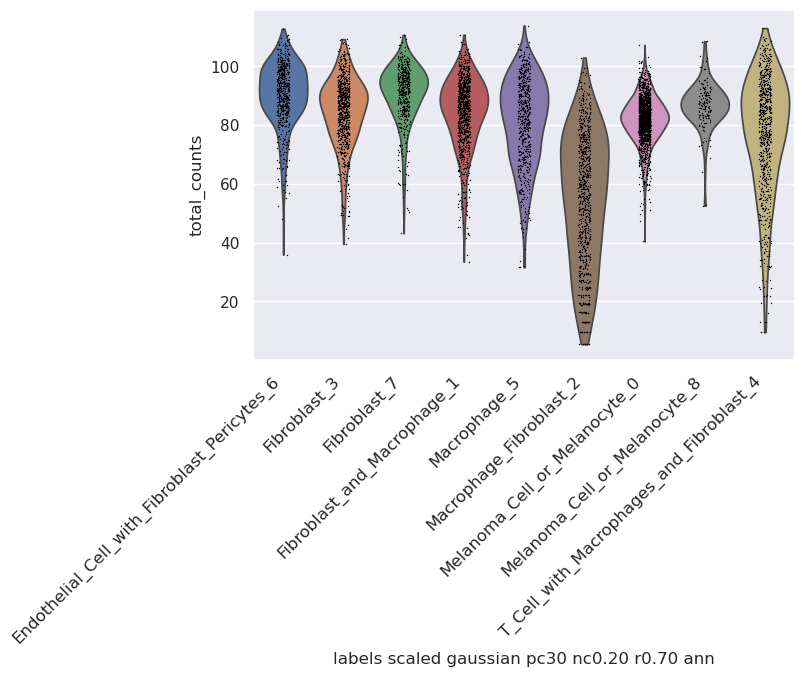

In [44]:
# Set the figure directory to your desired location
sc.settings.figdir = qc_path

## Total counts across unlabeled clustered
plt.figure(figsize=(8, 6))
ax = sc.pl.violin(
    adata, 
    "total_counts", 
    groupby=cluster_ann_col,
    show=False
    )

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    va="top",
    fontsize=12
)

plt.tight_layout()
plt.savefig(
    os.path.join(
        qc_path,
        f"violin_total_counts_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [45]:
adata.obs[cluster_col].astype(str).value_counts().sort_index()
adata.obs[cluster_ann_col].value_counts(dropna=False)

labels_scaled_gaussian_pc30_nc0.20_r0.70_ann
Melanoma_Cell_or_Melanocyte_0                   1581
Fibroblast_and_Macrophage_1                      994
Macrophage_Fibroblast_2                          806
Fibroblast_3                                     792
T_Cell_with_Macrophages_and_Fibroblast_4         750
Macrophage_5                                     597
Endothelial_Cell_with_Fibroblast_Pericytes_6     594
Fibroblast_7                                     495
Melanoma_Cell_or_Melanocyte_8                    151
Name: count, dtype: int64

In [46]:
print(cluster_col)
print(cluster_ann_col)
print(adata.obs[cluster_col].nunique())
print(adata.obs[cluster_ann_col].nunique())

labels_scaled_gaussian_pc30_nc0.20_r0.70
labels_scaled_gaussian_pc30_nc0.20_r0.70_ann
9
9


In [47]:
# # ---------------------------------------------------------------------------- #
# #                        TOP EXPRESSED GENES PER CLUSTER                       #
# # ---------------------------------------------------------------------------- #
# ### Spatial clustering results

# import scanpy as sc

# ## Rank genes and identify cluster gene markers
# sc.tl.rank_genes_groups(
#     adata,
#     groupby=cluster_col,
#     method='wilcoxon',
#     key_added=f"{cluster_col}_markers"
# )



In [48]:


# # ---------------------------------------------------------------------------- #
# #                                CLUSTER HEATMAP                               #
# # ---------------------------------------------------------------------------- #

# # Set the figure directory to your desired location
# sc.settings.figdir = output_path

# ## Generate heat map for top markers per cluster
# sc.tl.dendrogram(
#     adata,
#     groupby=cluster_col,
#     key_added=cluster_col
# )

# ## Determine vmin and vmax dynamically based on gene expression.
# ## Convert matrix-like/sparse values to a plain ndarray so NumPy percentiles
# ## do not inherit np.matrix multiplication semantics.
# expr_values = adata.X
# if hasattr(expr_values, "toarray"):
#     expr_values = expr_values.toarray()
# expr_values = np.asarray(expr_values).ravel()
# positive_expr_values = expr_values[expr_values > 0]
# if positive_expr_values.size == 0:
#     vmax_dynamic = 0
# else:
#     vmax_dynamic = np.percentile(positive_expr_values, 99)
# vmin_dynamic = np.percentile(expr_values, 1)

# sc.pl.rank_genes_groups_heatmap(
#     adata, 
#     key=f"{cluster_col}_markers_raw",
#     #key= 'raw_test',
#     n_genes=5,
#     cmap = "plasma",
#     vmin=vmin_dynamic,
#     vmax=vmax_dynamic,
#     show_gene_labels = True,
#     save = f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_raw_markers.png",
#     figsize=(20, 15)
# )




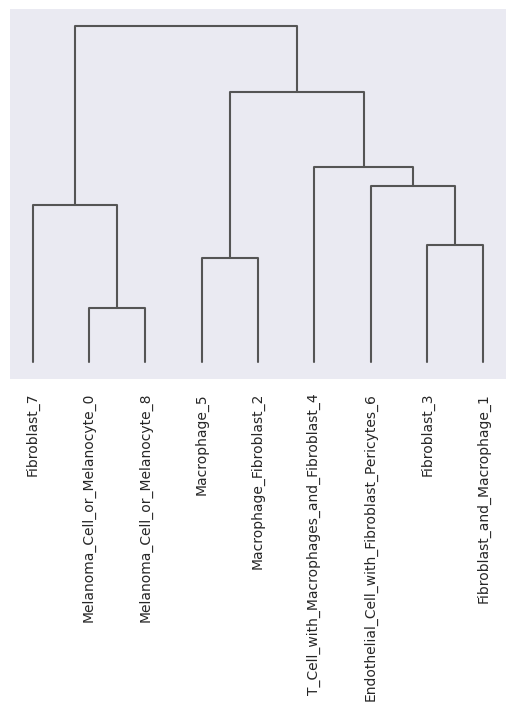

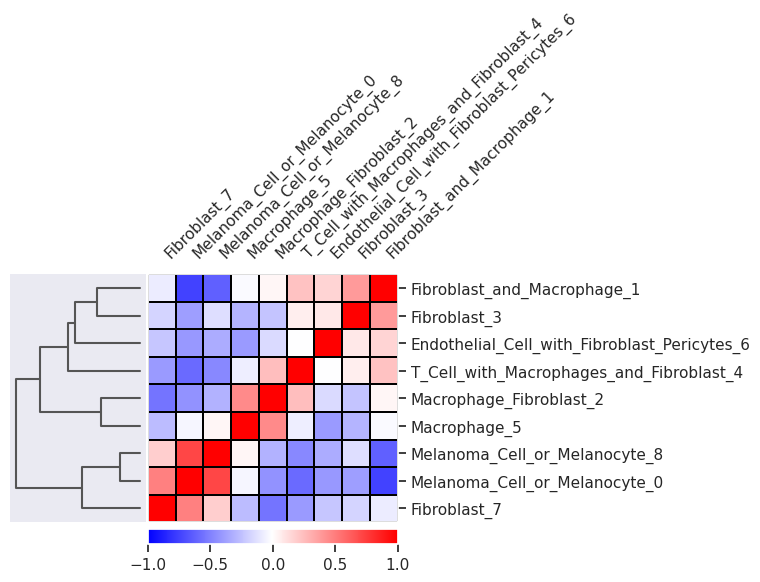

In [49]:


# ---------------------------------------------------------------------------- #
#                  GENERATE DENDROGRAM AND CORRELATION MATRIX                  #
# ---------------------------------------------------------------------------- #
groupby_key = cluster_ann_col

sc.tl.dendrogram(adata, groupby=groupby_key)

sc.pl.dendrogram(
    adata,
    groupby=groupby_key,
    save=f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
)

sc.pl.correlation_matrix(
    adata,
    groupby = groupby_key,
    save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_cluster_correlation_plot.png",
    figsize=(5, 3.5)
)


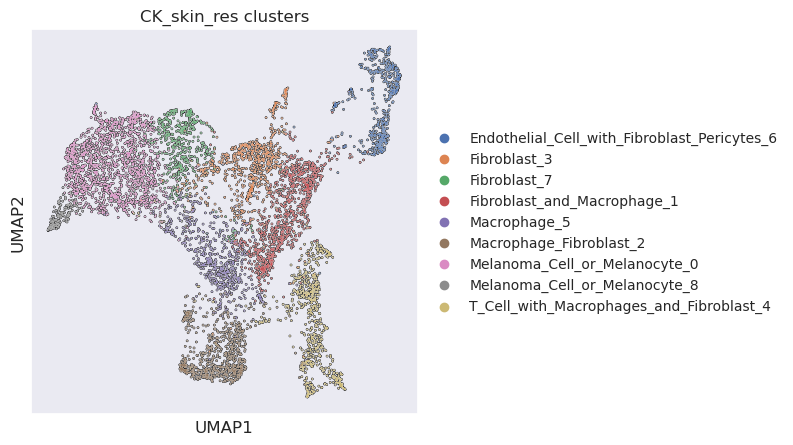

In [50]:

# ---------------------------------------------------------------------------- #
#                                ANNOTATED UMAP                                #
# ---------------------------------------------------------------------------- #

### Cluster Annotated UMAP
## Plot the umap with bulk labels
import scanpy as sc
from matplotlib.pyplot import rc_context

color_vars = [
cluster_ann_col
]

with rc_context({"figure.figsize": (5,5)}):
    sc.pl.umap(
        adata, 
        color=color_vars, 
        s=5, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=10,
        title=f"{dataset_name} clusters",
        save = f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
        )




In [51]:
# # ---------- Plot the UMAP coloured by negative control probe counts --------- #
# fig, axes = plot_umap_qc_metric(
#     adata=adata,
#     cluster_col=cluster_ann_col,
#     qc_metric="negative_control_probe_greater_equal_1_cat",
#     dataset_name=dataset_name,
#     qc_path=qc_umap_path,
#     qc_title="Cells with >= 1 negative control probe count",
# )

In [52]:
# # --------------- Plot the UMAP coloured by minimum transcripts -------------- #
# fig, axes = plot_umap_qc_metric(
#     adata=adata,
#     cluster_col=cluster_ann_col,
#     qc_metric="min_trans_passed_cat",
#     dataset_name=dataset_name,
#     qc_path=qc_umap_path,
#     qc_title="Minimum transcript (n=10) threshold",
# )

In [53]:
# # --------------- Plot the UMAP coloured by maximum transcripts -------------- #
# fig, axes = plot_umap_qc_metric(
#     adata=adata,
#     cluster_col=cluster_ann_col,
#     qc_metric="max_trans_passed_cat",
#     dataset_name=dataset_name,
#     qc_path=qc_umap_path,
#     qc_title="Maximum transcript threshold (top 2%)",
# )

In [54]:
# # ------------ Plot the UMAP coloured by top 2% cells by cell area ----------- #
# fig, axes = plot_umap_qc_metric(
#     adata=adata,
#     cluster_col=cluster_ann_col,
#     qc_metric="max_area_threshold_98_cat",
#     dataset_name=dataset_name,
#     qc_path=qc_umap_path,
#     qc_title="Top 2% of cells by cell area"
# )

In [55]:
# # ------------ Plot the UMAP coloured by top 1% cells by cell area ----------- #
# fig, axes = plot_umap_qc_metric(
#     adata=adata,
#     cluster_col=cluster_ann_col,
#     qc_metric="max_area_threshold_99_cat",
#     dataset_name=dataset_name,
#     qc_path=qc_umap_path,
#     qc_title="Top 1% of cells by cell area"
# )

In [56]:
# # ---------- Plot the UMAP coloured by bottom 1% cells by cell area ---------- #
# fig, axes = plot_umap_qc_metric(
#     adata=adata,
#     cluster_col=cluster_ann_col,
#     qc_metric="min_area_threshold_1_cat",
#     dataset_name=dataset_name,
#     qc_path=qc_umap_path,
#     qc_title="Bottom 1% of cells by cell area"
# )

In [57]:
# # ---------- Plot the UMAP coloured by bottom 2% cells by cell area ---------- #
# fig, axes = plot_umap_qc_metric(
#     adata=adata,
#     cluster_col=cluster_ann_col,
#     qc_metric="min_area_threshold_2_cat",
#     dataset_name=dataset_name,
#     qc_path=qc_umap_path,
#     qc_title="Bottom 2% of cells by cell area"
# )

In [ ]:
# ----------------------- Plot UMAPs for all qc metrics ---------------------- #

## Define the qc_metric and qc_title pairs

qc_umap_plots = [
    ("negative_control_probe_greater_equal_1_cat", "Negative-control probe count >= 1"),
    ("min_trans_passed_cat", "Minimum transcript threshold"),
    ("max_trans_passed_cat", "Top 2% transcript count threshold"),
    ("max_area_threshold_99_cat", "Top 1% of cells by cell area"),
    ("max_area_threshold_98_cat", "Top 2% of cells by cell area"),
    ("min_area_threshold_1_cat", "Bottom 1% of cells by cell area"),
    ("min_area_threshold_2_cat", "Bottom 2% of cells by cell area")
]

filter_stage_label = filter_stage.replace("_", " ")

# Plot raw BANKSY clusters for every available resolution. These match the
# resolution-aware violin plots and are used for QC inspection across clusterings.
for res in res_label_list:
    cluster_col_for_res = (
        f"labels_{nbr_weight_decay}_pc{pc_label}_nc{lambda_label}_r{float(res):.2f}"
    )

    if cluster_col_for_res not in adata.obs.columns:
        print(f"Skipping missing cluster column: {cluster_col_for_res}")
        continue

    for qc_metric, qc_title in qc_umap_plots:
        if qc_metric not in adata.obs.columns:
            print(f"Skipping missing QC metric: {qc_metric}")
            continue

        plot_umap_qc_metric(
            adata=adata,
            cluster_col=cluster_col_for_res,
            qc_metric=qc_metric,
            dataset_name=dataset_name,
            qc_path=qc_umap_path,
            qc_title=qc_title,
            cluster_title=f"{dataset_name} clusters",
            filename_tag=f"{filter_stage}_r{res}",
            title_tag=f"{filter_stage_label} | resolution {float(res):.2f}"
        )

# Keep annotated UMAPs separate so the manually interpreted cluster labels can
# be compared before and after filtering without mixing them into all resolutions.
if cluster_ann_col in adata.obs.columns:
    for qc_metric, qc_title in qc_umap_plots:
        if qc_metric not in adata.obs.columns:
            print(f"Skipping missing QC metric: {qc_metric}")
            continue

        plot_umap_qc_metric(
            adata=adata,
            cluster_col=cluster_ann_col,
            qc_metric=qc_metric,
            dataset_name=dataset_name,
            qc_path=qc_umap_path,
            qc_title=qc_title,
            cluster_title=f"{dataset_name} annotated clusters",
            filename_tag=f"{filter_stage}_annotated_r{plot_res_label}",
            title_tag=f"{filter_stage_label} | annotated resolution {float(plot_res_label):.2f}"
        )
else:
    print(f"Skipping annotated QC UMAP plots; missing column: {cluster_ann_col}")



# In[ ]:




# In[ ]:




In [ ]:
# ---------------------------------------------------------------------------- #
#        PRE-FILTER QC UMAPS USING MANUALLY ANNOTATED CLUSTER LABELS           #
# ---------------------------------------------------------------------------- #
filter_stage = "pre_filter"
filter_stage_label = filter_stage.replace("_", " ")

qc_umap_plots = [
    ("negative_control_probe_greater_equal_1_cat", "Negative-control probe count >= 1"),
    ("min_trans_passed_cat", "Minimum transcript threshold"),
    ("max_trans_passed_cat", "Top 2% transcript count threshold"),
    ("max_area_threshold_99_cat", "Top 1% of cells by cell area"),
    ("max_area_threshold_98_cat", "Top 2% of cells by cell area"),
    ("min_area_threshold_1_cat", "Bottom 1% of cells by cell area"),
    ("min_area_threshold_2_cat", "Bottom 2% of cells by cell area"),
]

if cluster_ann_col in adata.obs.columns:
    for qc_metric, qc_title in qc_umap_plots:
        if qc_metric not in adata.obs.columns:
            print(f"Skipping missing QC metric: {qc_metric}")
            continue

        plot_umap_qc_metric(
            adata=adata,
            cluster_col=cluster_ann_col,
            qc_metric=qc_metric,
            dataset_name=dataset_name,
            qc_path=qc_umap_path,
            qc_title=qc_title,
            cluster_title=f"{dataset_name} annotated clusters",
            filename_tag=f"{filter_stage}_annotated_r{plot_res_label}",
            title_tag=f"{filter_stage_label} | annotated resolution {float(plot_res_label):.2f}",
        )
else:
    print(f"Skipping annotated QC UMAP plots; missing column: {cluster_ann_col}")


# In[ ]:




In [ ]:
# ---------------------------------------------------------------------------- #
#                              SET PATHS FOR PLOTS                             #
# ---------------------------------------------------------------------------- #

## Create a path for gene of interest UMAP plots
umap_path = os.path.join(output_path, "umap")

if not os.path.isdir(umap_path):
    os.makedirs(umap_path)
    print(f"Directory '{umap_path}' created successfully.")
    
else:
    print(f"Directory '{umap_path}' already exists.")


## Create a path for gene of interest violin plots
violin_path = os.path.join(output_path, "violin")

if not os.path.isdir(violin_path):
    os.makedirs(violin_path)
    print(f"Directory '{violin_path}' created successfully.")
    
else:
    print(f"Directory '{violin_path}' already exists.")

## Create a path for gene of interest dot plots
dotplot_path = os.path.join(output_path, "dotplot")

if not os.path.isdir(dotplot_path):
    os.makedirs(dotplot_path)
    print(f"Directory '{dotplot_path}' created successfully.")
    
else:
    print(f"Directory '{dotplot_path}' already exists.")

## Create a path for gene of interest UMAP plots
neighbour_path = os.path.join(output_path, "neighbourhood_centrality_co-occurence")

if not os.path.isdir(neighbour_path):
    os.makedirs(neighbour_path)
    print(f"Directory '{neighbour_path}' created successfully.")
    
else:
    print(f"Directory '{neighbour_path}' already exists.")


## Create a path for gene of interest spatial scatter plots
spatial_scatter_path = os.path.join(output_path, "spatial_scatter")

if not os.path.isdir(spatial_scatter_path):
    os.makedirs(spatial_scatter_path)
    print(f"Directory '{spatial_scatter_path}' created successfully.")
    
else:
    print(f"Directory '{spatial_scatter_path}' already exists.")

In [ ]:
# ---------------------------------------------------------------------------- #
#                        GENE OF INTEREST UMAP FUNCTION                        #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = umap_path
def plot_goi_umaps (
    genes: list,
    adata,
    sample_name: str,
    s: int = 20,
    **kwargs #additional sc.pl.umap arguments such as ncols
):
    title_list = []

    for i in genes:
        title = f"{i} expression in {sample_name}"
        title_list.append(title)
        gene_str = "_".join(genes)

    with rc_context({"figure.figsize": (8,5)}):
        sc.pl.umap(
            adata, 
            color=genes, 
            s=20, 
            frameon=True, 
            vmax="p99",
            add_outline=True,
            legend_fontsize=9,
            title=title_list,
            save = f"_{sample_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_{gene_str}_response_genes.png",
            **kwargs
            )




In [ ]:


## DSG2 UMAP
plot_goi_umaps(genes=["DSG2", "TPD52L2"],
adata=adata,
sample_name= dataset_name,
s=20, )




In [ ]:


## SERPINE1 UMAP
plot_goi_umaps(genes=["SERPINE1"],
adata=adata,
sample_name= dataset_name,
s=20, )




In [ ]:


### DKK1

plot_goi_umaps(genes=["DKK1"],
adata=adata,
sample_name= dataset_name,
s=20, )




In [ ]:


### T cell markers

plot_goi_umaps(genes=["FOXP3", "GZMB"],
adata=adata,
sample_name= dataset_name,
s=20, )




In [ ]:


### Integrin genes

plot_goi_umaps(genes=[
"ITGAE", 
"ITGA1", 
"ITGA4",
"ITGA5"],
adata=adata,
sample_name= dataset_name,
s=20,
ncols=2
)




In [ ]:


# ### TPD52 family

plot_goi_umaps(genes=[
"TPD52", 
"TPD52L1", 
"TPD52L2"
],
adata=adata,
sample_name= dataset_name,
s=20,
ncols=2
)




In [ ]:


#### Selectins

plot_goi_umaps(genes=[
"SELE", 
"SELL", 
"SELP"
],
adata=adata,
sample_name= dataset_name,
s=20,
ncols=2
)




In [ ]:


# ### Fucosyltransferase genes

plot_goi_umaps(genes=[
"FUT6", 
"FUT7"
],
adata=adata,
sample_name= dataset_name,
s=20
)




In [ ]:


# ### Adhesion molecules

plot_goi_umaps(genes=[
"VCAM1", 
"ICAM1"
],
adata=adata,
sample_name= dataset_name,
s=20
)




In [ ]:


# ### ICI response genes

plot_goi_umaps(genes=[
"PDCD1", 
"CD274", 
"CTLA4"
],
adata=adata,
sample_name= dataset_name,
s=20
)




In [ ]:


# ---------------------------------------------------------------------------- #
#                         GENE EXPRESSION VIOLIN PLOTS                         #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = violin_path

with rc_context({"figure.figsize": (10, 8)}):
    ax= sc.pl.violin(
        adata,
        ["nFeature_Xenium"],
        groupby=cluster_ann_col,
        rotation=270,
        stripplot=False,  # remove the internal dots
        inner="box",  # adds a boxplot inside violins
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_gene_count_per_cluster_violin_plot.png"
    )




In [ ]:


#### DSG2

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata, 
        keys = [
            "DSG2"
            ], 
        #groupby=cluster_col,
        groupby=cluster_ann_col,
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("DSG2 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DSG2_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)




In [ ]:


#### SERPINE1

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata, 
        keys = [
            "SERPINE1"
            ], 
        groupby=cluster_ann_col,
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("SERPINE1 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_SERPINE1_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)




In [ ]:


#### DKK1

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata, 
        keys = [
            "DKK1"
            ], 
        groupby=cluster_ann_col,
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("DKK1 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DKK1_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)




In [ ]:


#### T cell markers

with rc_context({"figure.figsize": (10,8)}):
   axes = sc.pl.violin(
        adata, 
        keys = [
             "FOXP3", 
             "GZMB"
            ], 
        #groupby=cluster_col,
        groupby=cluster_ann_col,
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )

# Apply customisation to each graph axis
for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Cell type', fontsize=12)

axes[0].set_ylabel("T cell markers expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_T_cell_markers_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)




In [ ]:


#### Integrins

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata, 
        [
            "ITGAE", 
            "ITGA1", 
            "ITGA4",
            "ITGA5"
            ], 
        #groupby=cluster_col,
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_integrin_genes_violin_plot.png"
        )




In [ ]:


#### TPD52 genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata, 
        [
            "TPD52",
            "TPD52L1",
            "TPD52L2"
            ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_TPD52_genes_violin_plot.png"
        )




In [ ]:


##### Selectins

with rc_context({"figure.figsize": (6,5)}):
    sc.pl.violin(
        adata, 
        [
        "SELE", 
        "SELL", 
        "SELP"
        ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_selectin_genes_violin_plot.png"
        )




In [ ]:


#### Fucosyltransferase genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata, 
        [
            "FUT6", 
            "FUT7"
        ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_fucosyltransferase_genes_violin_plot.png"
        )




In [ ]:


# ### Adhesion genes

with rc_context({"figure.figsize": (6,5 )}):
    sc.pl.violin(
        adata, 
        [
            "VCAM1",
            "ICAM1"
        ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_adhesion_genes_violin_plot.png"
        )




In [ ]:


# ### ICI response genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata, 
        [
            "PDCD1", 
            "CD274", 
            "CTLA4"
        ], 
        groupby=cluster_ann_col,
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_adhesion_genes_violin_plot.png"
        )




In [ ]:


# ---------------------------------------------------------------------------- #
#                           Gene expression dot plots                          #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = dotplot_path
adata.obs[cluster_ann_col]




In [ ]:


# --------------------------- Tier gene 1 dotplots --------------------------- #

#### Dot plot function
def plot_goi_dotplot (
    adata,
    cell_type_savename: str,
    marker_genes_dict: dict, #dictionary such as {"Melanoma : ['TYR', 'EDNRB']"}
    s: int = 20,
    **kwargs #additional sc.pl.umap arguments such as ncols or dendrogram = True
):

    with rc_context({"figure.figsize": (10,10)}):
        sc.pl.dotplot(
            adata, 
            marker_genes_dict,
            groupby=cluster_ann_col,
            save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_{cell_type_savename}_dot_plot.png",
            **kwargs
            )




In [ ]:


# Set the figure directory to your desired location
sc.settings.figdir = dotplot_path




In [ ]:


# ---------------------------------------------------------------------------- #
#                       NEIGHBOURHOOD ENRICHMENT ANALYSIS                      #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = neighbour_path




In [ ]:


# Adding spatial coordinates to .obsm
adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()




In [ ]:


sq.gr.spatial_neighbors(adata)

cluster_key = cluster_ann_col
sq.gr.nhood_enrichment(adata, cluster_key=cluster_key)

with rc_context({"figure.figsize": (10,10)}):
    sq.pl.nhood_enrichment(
        adata, 
        cluster_key=cluster_key,
        save=f"neighbourhood_enrichment_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png")




In [ ]:


# ---------------------------------------------------------------------------- #
#                      MORAN'S I SCORE OF AUTOCORRELATION                      #
# ---------------------------------------------------------------------------- #

from spatialdata import SpatialData
adata.obs.rename(columns={"cell type": "cell_type"}, inplace=True)

# Create SpatialData with a single table (the AnnData)
sdata = SpatialData(tables={"cells": adata})

# Perform Moran's I calculation
sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)
adata_subsample = sdata.tables["subsample"]

sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)




In [ ]:


## Store moran I scores as a data frame
moran_scores = adata_subsample.uns["moranI"]
moran_scores = moran_scores.reset_index(names=["Gene"])

## Exclude _nbr_0 and _nbr_1
moran_scores_raw = moran_scores[~moran_scores["Gene"].str.contains("_nbr_0", case=False, na=False)]
moran_scores_raw = moran_scores_raw[~moran_scores_raw["Gene"].str.contains("_nbr_1", case=False, na=False)]

## Filter for genes that have an FDR if less than 10%
moran_scores_raw = moran_scores_raw[moran_scores_raw["pval_sim_fdr_bh"] <= 0.10]

## Write Moran I scores to .csv
moran_scores_raw.to_csv(f"{processed_path}/moran_scores_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.csv")




In [ ]:


## Plot spatial scatter plots for genes with the top 10 highest Moran I scores

## Create a list of the top scoring genes
top_moran = moran_scores_raw.sort_values(by="pval_sim", ascending=True)
top_moran = top_moran.iloc[:10]
top_moran = list(top_moran['Gene'])
top_moran

for i in top_moran:
    with rc_context({"figure.figsize": (12,8)}):
        sq.pl.spatial_scatter(
            adata_subsample,
            library_id="spatial",
            color=[i],
            shape=None,
            size=2,
            img=False,
            save= f"spatial_scatter_top_moran_I_{i}_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
)




In [ ]:


# ###############################################
# #       COMPUTE AND PLOT CENTRALITY SCORE     #
# ###############################################
# # ## Compute centrality scores
# sq.gr.centrality_scores(adata_subsample, cluster_key=cluster_key)
# sq.pl.centrality_scores(adata_subsample, cluster_key=cluster_key, figsize=(22, 4))

# ### Compute co-occurence probability
# from spatialdata import SpatialData
# sdata = SpatialData()
# sdata.tables["subsample"] = sc.pp.subsample(adata_subsample, fraction=0.5, copy=True)
# cluster_keys = list(new_labels.keys())

# cluster_key_label = cluster_col

# ## Calculate and plot the co-occurence of clusters
# sq.gr.co_occurrence(
#     adata_subsample,
#     cluster_key=cluster_key_label
#     )


# for i in cluster_keys:     
#     cluster_number = str(i)
     
#     with rc_context({"figure.figsize": (12,12)}):
#         sq.pl.co_occurrence(
#             adata_subsample,
#             cluster_key=cluster_key_label,
#             clusters=i,
#             figsize=(10, 10),
#             save=f"co-occurence_cluster_{cluster_number}_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
#             )

# with rc_context({"figure.figsize": (12,8)}):
#     sq.pl.spatial_scatter(
#         adata_subsample,
#         library_id="dataset_name",
#         color=cluster_key_label,
#         shape=None,
#         size=2,
#         save=f"spatial_cluster_scatter_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
#         )




In [ ]:


# ---------------------------------------------------------------------------- #
#                   SPATIAL EXPRESSION FOR GENES OF INTEREST                   #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = spatial_scatter_path

goi_list = [
    "DSG2",
    "SERPINE1",
    "DKK1",
    "FOXP3", 
    "GZMB",
    "ITGAE",
    "ITGA1",
    "ITGA4",
    "ITGA5",
    "TPD52",
    "TPD52L1",
    "TPD52L2",
    "SELE", 
    "SELL", 
    "SELP",
    "FUT6", 
    "FUT7",
    "VCAM1",
    "ICAM1",
    "PDCD1", 
    "CD274", 
    "CTLA4",
]

# Set the figure directory to your desired location
sc.settings.figdir = spatial_scatter_path

for gene in goi_list:
    sq.pl.spatial_scatter(
        adata_subsample,
        library_id="spatial",
        color=[gene],
        shape=None,
        size=2,
        img=False,
        save= f"spatial_scatter_{gene}_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
)

